In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('clean_data.csv')
df_original = df

In [2]:
df.head()

,Unnamed: 0,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier,cantidad_log
0,1,2023-05-25,Leche entera,Lácteos,4,1.20,4.8,Efectivo,False,1.609438
1,2,2023-08-19,Bolsas plásticas,Descartables,6,0.10,0.6,Tarjeta débito,False,1.945910
2,4,2024-12-10,Carne molida,Carnes,1,5.80,5.8,Tarjeta débito,False,0.693147
3,6,2023-01-11,Refresco 2L,Bebidas,3,1.10,3.3,Efectivo,False,1.386294
4,7,2024-07-03,Pasta de Tomate,Enlatados,2,0.75,1.5,Efectivo,False,1.098612


In [3]:
df.tail(2)

,Unnamed: 0,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier,cantidad_log
22638,28355,2023-10-21,Leche entera,Lácteos,1,1.2,1.2,Transferencia,False,0.693147
22639,28357,2023-09-09,Leche entera,Lácteos,2,1.2,2.4,QR,False,1.098612


In [4]:
df = df.drop(columns = 'Unnamed: 0')

In [5]:
df = df.drop(columns = 'es_outlier')

In [6]:
df.head(5)

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,cantidad_log
0,2023-05-25,Leche entera,Lácteos,4,1.20,4.8,Efectivo,1.609438
1,2023-08-19,Bolsas plásticas,Descartables,6,0.10,0.6,Tarjeta débito,1.945910
2,2024-12-10,Carne molida,Carnes,1,5.80,5.8,Tarjeta débito,0.693147
3,2023-01-11,Refresco 2L,Bebidas,3,1.10,3.3,Efectivo,1.386294
4,2024-07-03,Pasta de Tomate,Enlatados,2,0.75,1.5,Efectivo,1.098612


In [7]:
df.describe()

,cantidad,precio_unitario,total,cantidad_log
count,22640.000000,22640.000000,22640.000000,22640.000000
mean,3.499337,2.159170,4.569457,1.306148
std,3.268010,1.831153,4.223625,0.596847
min,1.000000,0.100000,0.100000,0.693147
25%,1.000000,0.900000,1.500000,0.693147
50%,2.000000,1.200000,3.600000,1.098612
75%,5.000000,4.000000,5.800000,1.791759
max,26.000000,5.800000,29.000000,3.295837


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22640 entries, 0 to 22639
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            22640 non-null  str    
 1   producto         22640 non-null  str    
 2   categoria        22640 non-null  str    
 3   cantidad         22640 non-null  int64  
 4   precio_unitario  22640 non-null  float64
 5   total            22640 non-null  float64
 6   metodo_pago      22640 non-null  str    
 7   cantidad_log     22640 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 1.4 MB


In [9]:
df['fecha'] = pd.to_datetime(df['fecha'])
df['fecha'].dtype

dtype('<M8[us]')

In [10]:
#Lets check the prices in the aviable data
prices = df['precio_unitario'].unique()
print(type(prices))
print('\n',prices)
prices.sort(axis = 0)
print('\n',type(prices))
print('\nThe prices in order are: ',prices)

<class 'numpy.ndarray'>

 [1.2  0.1  5.8  1.1  0.75 3.2  4.5  0.9  4.   2.3 ]

 <class 'numpy.ndarray'>

The prices in order are:  [0.1  0.75 0.9  1.1  1.2  2.3  3.2  4.   4.5  5.8 ]


In [11]:
# Show product and price order by category
test = df[['categoria', 'producto', 'precio_unitario']].sort_values(by='precio_unitario')
print(test.duplicated().sum())
test = test.drop_duplicates()
print(test.duplicated().sum())
#test.sort_values(by=["precio_unitario"])
test = test.reset_index()
test = test.drop(columns = 'index')
print(test)

22630
0
      categoria            producto  precio_unitario
0  Descartables    Bolsas plásticas             0.10
1     Enlatados     Pasta de Tomate             0.75
2       Lácteos      Yogurt natural             0.90
3       Bebidas         Refresco 2L             1.10
4       Lácteos        Leche entera             1.20
5    Congelados  Papas precocinadas             2.30
6     Embutidos       Jamón de pavo             3.20
7       Lácteos     Helado familiar             4.00
8        Carnes        Pollo entero             4.50
9        Carnes        Carne molida             5.80


### Analizaré primero la variable cantidad y cantidad_log:   (FIIIIIIIIIX)

In [12]:
#For that i will work in the date column and create another ones

In [13]:
df['fecha'].max()

Timestamp('2024-12-11 00:00:00')

In [14]:
df['fecha'].min()

Timestamp('2023-01-03 00:00:00')

In [15]:
#Crear columnas dia, mes ,año para analizar finanzas ysuma.
#Analizar las tendencias en esos invervalos de tiempo.
df['day'] = df['fecha'].dt.day
df['month'] = df['fecha'].dt.month
df['year'] = df['fecha'].dt.year

In [16]:
meses = df.sort_values(by = 'fecha')

In [17]:
meses.head()

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,cantidad_log,day,month,year
1455,2023-01-03,Bolsas plásticas,Descartables,10,0.10,1.0,Efectivo,2.397895,3,1,2023
9945,2023-01-03,Bolsas plásticas,Descartables,9,0.10,0.9,Tarjeta crédito,2.302585,3,1,2023
14603,2023-01-03,Yogurt natural,Lácteos,5,0.90,4.5,Efectivo,1.791759,3,1,2023
4081,2023-01-03,Helado familiar,Lácteos,1,4.00,4.0,Tarjeta crédito,0.693147,3,1,2023
19041,2023-01-03,Pasta de Tomate,Enlatados,4,0.75,3.0,Tarjeta crédito,1.609438,3,1,2023


In [18]:
meses = meses[['month','year']]

In [19]:
meses.tail()

,month,year
10342,12,2024
19669,12,2024
19952,12,2024
19137,12,2024
5349,12,2024


In [20]:
meses = meses.drop_duplicates()

### Analicemos simetría de los datos:

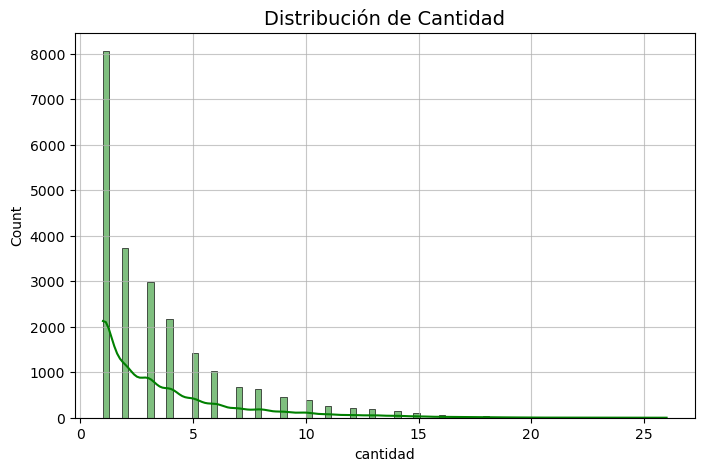

In [21]:
plt.figure(figsize=(8, 5))

# Histoplot
ax1 = sns.histplot(df['cantidad'], kde=True, color='green')

# Personalization
ax1.set_title('Distribución de Cantidad', fontsize=14)
ax1.grid(True, linestyle='-', alpha=0.7) # grid

plt.show()

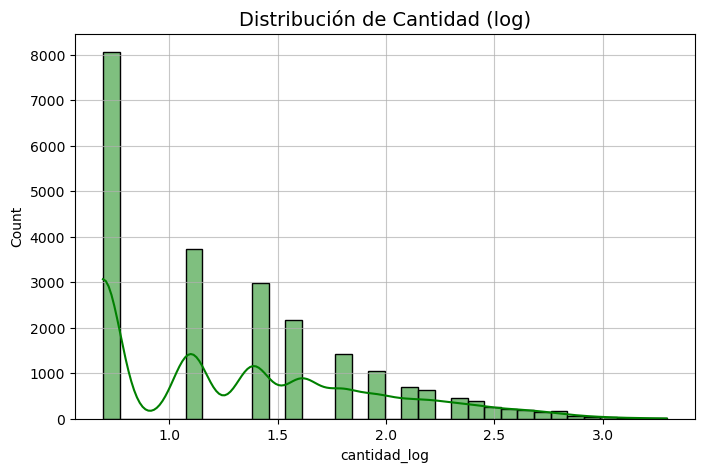

In [22]:
plt.figure(figsize=(8, 5))

# Histoplot
ax1 = sns.histplot(df['cantidad_log'], kde=True, color='green')

# Personalization
ax1.set_title('Distribución de Cantidad (log)', fontsize=14)
ax1.grid(True, linestyle='-', alpha=0.7) # grid

plt.show()

No hay mucha diferencia visual entre la distribución de cantidad y cantidad_log.

In [23]:

print('We have a Skewness of: ',df['cantidad'].skew(),
     '\nWe have a Kurtosis of: ',df['cantidad'].kurtosis())

We have a Skewness of:  1.973012201696746 
We have a Kurtosis of:  4.597479543314638


In [24]:
print('We have a Skewness of: ',df['cantidad_log'].skew(),
     '\nWe have a Kurtosis of: ',df['cantidad_log'].kurtosis())

We have a Skewness of:  0.6731889685166196 
We have a Kurtosis of:  -0.48580771038696735


- Aunque el valor de skewness es aun distante de cero, actualmente es menor que refiriéndose a df['cantidad'].
- Se nota en la distribución de ventas un sesgo existente habiendo una cola a la derecha, estos son valores reales registrados.
- En la frecuencia de registros (filas) registrados por mes se nota una tendencia estacional (seasonal).
- Leptocúrtica (Curtosis $> 0$) esto indica que existe concentración de datos cerca de la media pero también que hay probabilidad de la existencia de outliers (como es apreciado con la presencia de colas en este caso a la derecha) 

### Evolución de ventas

In [25]:
# Group by year and month
evolucion_cols = pd.pivot_table(df, index=['year','month'], values='cantidad',aggfunc='sum')


In [26]:
# Preparar los datos (Convertir el MultiIndex a columnas y crear una etiqueta temporal)
df_plot = evolucion_cols.reset_index()
df_plot['fecha'] = df_plot['year'].astype(str) + '-' + df_plot['month'].astype(str)

fig = px.line(df_plot, x='fecha', y='cantidad', text='cantidad', 
              title='Evolución de Ventas',
              height=600) # <--- Aquí se ajusta el alto de la figura

fig.update_traces(textposition="top center")
fig.show()



Venta mensual por categoría (usando la variable cantidad original para observar volumen real)

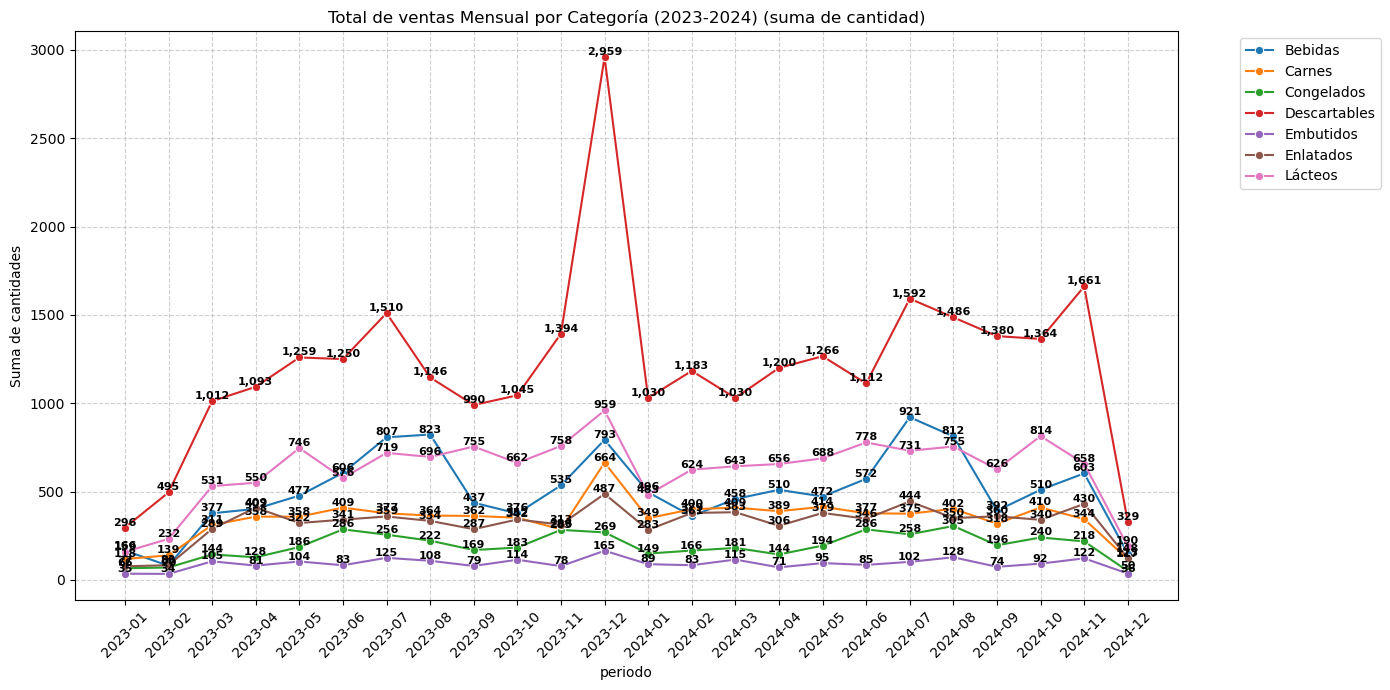

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Agrupación y preparación 
ventas_categoria_mes = df.groupby(['year', 'month', 'categoria'])['cantidad'].sum().reset_index(name='total_ventas')

ventas_categoria_mes['periodo'] = (
    ventas_categoria_mes['year'].astype(str) + "-" + 
    ventas_categoria_mes['month'].astype(str).str.zfill(2)
)

ventas_categoria_mes = ventas_categoria_mes.sort_values(['year', 'month'])

#  CREAR EL GRÁFICO (Faltaba esta parte)
plt.figure(figsize=(14, 7))
sns.lineplot(data=ventas_categoria_mes, x='periodo', y='total_ventas', hue='categoria', marker='o')

# MOSTRAR VALORES
# Usamos len(ventas_categoria_mes) para que coincida
for i in range(len(ventas_categoria_mes)):
    plt.text(
        x = ventas_categoria_mes.periodo.iloc[i], 
        y = ventas_categoria_mes.total_ventas.iloc[i], 
        s = f"{ventas_categoria_mes.total_ventas.iloc[i]:,.0f}", 
        color='black',
        va='bottom',    
        ha='center',    
        fontsize=8,    
        fontweight='semibold'
    )

#  CONFIGURACIÓN FINAL
plt.xticks(rotation=45)
plt.title('Total de ventas Mensual por Categoría (2023-2024) (suma de cantidad)')
plt.ylabel('Suma de cantidades')
# Ajuste: solo llamar a legend si hay un hue definido en el lineplot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
# Agrupar por fecha para ver la suma de ventas diarias de todos los productos
#Atendiendo a que cada fila representa una venta, debo sumar las ventas
#de cada día usando la columna cantidad.
cantFecha = df[['fecha','cantidad']]
#cantFecha = cantFecha.groupby('fecha').agg('sum')
# Aseguramos que sea fecha real y sumamos


In [29]:
#cantFecha['fecha'] = pd.to_datetime(cantFecha['fecha'])
#cantFecha['fecha'].dtype

In [30]:
#cantFecha = df.groupby(df['fecha'])['cantidad'].sum().reset_index()

In [31]:
#cantFecha

In [32]:
#import seaborn as sns
#import matplotlib.pyplot as plt
#sns.histplot(cantFecha, kde=True)
#plt.title('Distribución de la Cantidad de Ventas/Día')
#plt.show()

In [33]:
#Alternativa más eficiente
pd.pivot_table(df, index='fecha', values='cantidad',aggfunc='sum')

,cantidad
fecha,
2023-01-03,81
2023-01-04,108
2023-01-05,41
2023-01-06,142
2023-01-07,145
...,...
2024-12-07,94
2024-12-08,113
2024-12-09,89


### Se procede a analizar la variable total, desde el punto de vista de finanzas.

In [34]:
totalesPorFecha = df.groupby(['year', 'month', 'categoria'])['total'].sum().reset_index(name='ingresosTotales')
totalesPorFecha['periodo'] = (
    totalesPorFecha['year'].astype(str) + "-" + 
    totalesPorFecha['month'].astype(str).str.zfill(2)
)

In [35]:
totalesPorFecha.head()

,year,month,categoria,ingresosTotales,periodo
0,2023,1,Bebidas,182.6,2023-01
1,2023,1,Carnes,616.8,2023-01
2,2023,1,Congelados,151.8,2023-01
3,2023,1,Descartables,29.6,2023-01
4,2023,1,Embutidos,112.0,2023-01


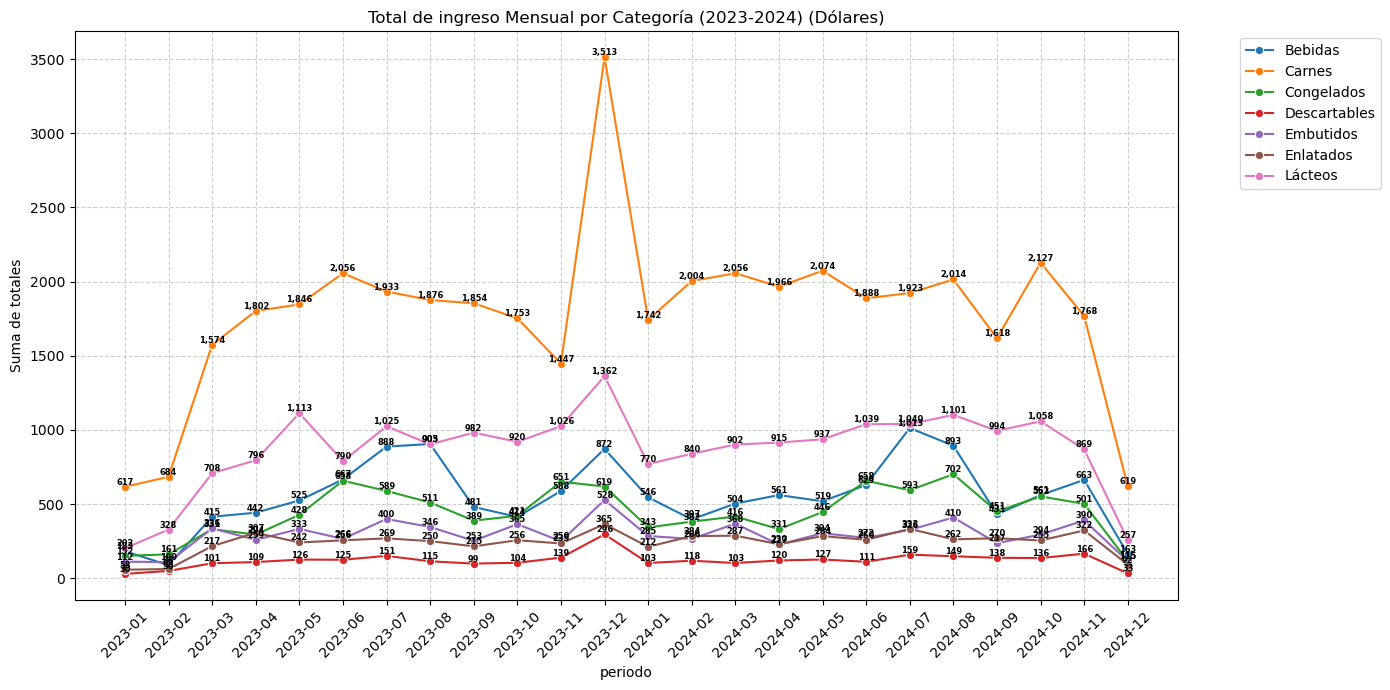

In [36]:
plt.figure(figsize=(14, 7))
plot = sns.lineplot(data=totalesPorFecha, x='periodo', y='ingresosTotales', hue='categoria', marker='o')

# --- Show values ---
for i in range(len(totalesPorFecha)):
    plt.text(
        x = totalesPorFecha.periodo.iloc[i], 
        y = totalesPorFecha.ingresosTotales.iloc[i], 
        # Formato de número: con comas y sin decimales (ej: 1,500)
        s = f"{totalesPorFecha.ingresosTotales.iloc[i]:,.0f}", 
        color='black',
        va='bottom',    # Alineación vertical: 'bottom' para que quede sobre el punto
        ha='center',    # Alineación horizontal: al centro
        fontsize=6,     # Tamaño de fuente un poco más pequeño
        fontweight='semibold'
    )
# ---------------------------------------

plt.xticks(rotation=45)
plt.title('Total de ingreso Mensual por Categoría (2023-2024) (Dólares)')
plt.ylabel('Suma de totales')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

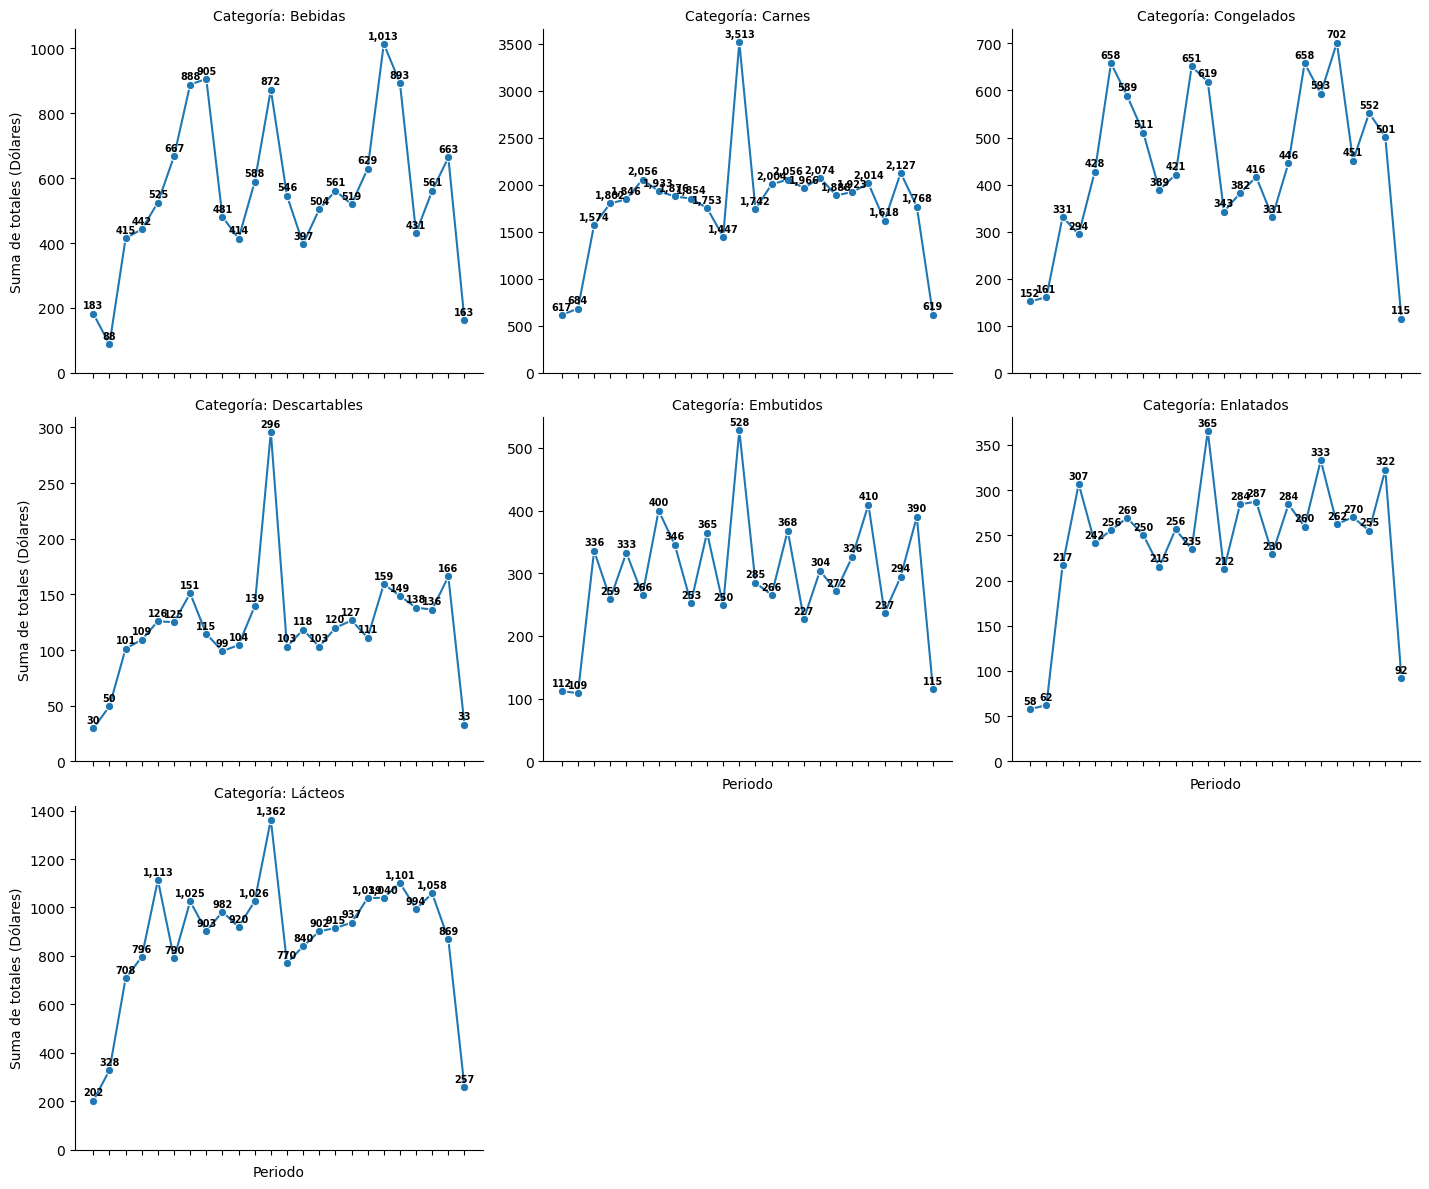

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

def anotar_puntos(data, **kwargs):
    ax = plt.gca()
    y_max = data['ingresosTotales'].max()
    offset = y_max * 0.01 
    for i in range(len(data)):
        valor = data['ingresosTotales'].iloc[i]
        ax.text(
            x = data['periodo'].iloc[i], 
            y = valor + offset, 
            s = f"{valor:,.0f}",
            va = 'bottom', 
            ha = 'center',
            fontsize = 7,
            fontweight = 'semibold'
        )

g = sns.relplot(
    data=totalesPorFecha, 
    x='periodo', 
    y='ingresosTotales', 
    col='categoria',      
    col_wrap=3,           
    kind='line', 
    marker='o',
    height=4,             
    aspect=1.2,
    facet_kws={'sharey': False}
)

g.map_dataframe(anotar_puntos)

g.set_xticklabels(rotation=45)
g.set_titles("Categoría: {col_name}")
g.set_axis_labels("Periodo", "Suma de totales (Dólares)")

total_max = totalesPorFecha['ingresosTotales'].max()
g.set(ylim=(0, None)) 

for ax in g.axes.flat:
    ax.margins(y=0.2)

plt.tight_layout()
plt.show()

In [38]:
df['categoria'].unique()

<StringArray>
[     'Lácteos', 'Descartables',       'Carnes',      'Bebidas',
    'Enlatados',    'Embutidos',   'Congelados']
Length: 7, dtype: str

In [39]:
categorias_a_comparar = df['categoria'].unique()
df_comparativa = totalesPorFecha[totalesPorFecha['categoria'].isin(categorias_a_comparar)]

fig = px.line(df_comparativa, x='periodo', y='ingresosTotales', 
              color='categoria', markers=True,
              title='Comparativa Interactiva de Tendencias',
              labels={'ingresosTotales': 'Ingresos (Dólares)'})

# Mostrar etiquetas encima de los puntos
fig.update_traces(textposition="top center", texttemplate='%{y:,.0f}')

fig.show()

De cierta forma, visualmente se aprecia una tendencia similar en los ingresos por categoría through time. **Esto indicaría correlación, analizar más adelante.**

In [40]:
finanzas_month = pd.pivot_table(df, index = ['month'], columns='year',values = 'total', aggfunc='sum')

<Axes: xlabel='month'>

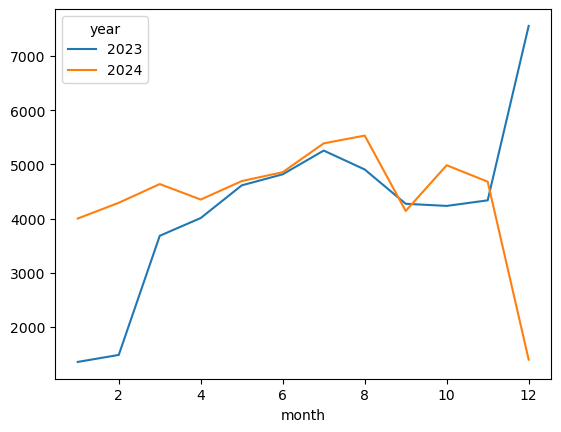

In [41]:
finanzas_month.plot()

### Checking sales by day

In [42]:
# Group by exact date
ingreso_por_dia = df.groupby('fecha')['total'].sum()

ingreso_por_dia = ingreso_por_dia.reset_index()
ingreso_por_dia.head(2)


,fecha,total
0,2023-01-03,106.5
1,2023-01-04,111.5


In [43]:
fig = px.line(ingreso_por_dia, x='fecha', y='total', 
              title='Ingreso total diario (suma)',
              height=500)

fig.update_traces(textposition="top center")
fig.show()

Observamos varios picos sobresalientes al resto de los días:

In [44]:
dias_ventas_superiores = ingreso_por_dia.loc[ingreso_por_dia['total']>1000]
fig = px.bar(dias_ventas_superiores, x='fecha', y='total',text='total', 
              title='Día de ingreso sobresaliente sobresalientes',
              height=500)
fig.update_traces(
    texttemplate='%{text:,.0f}', # Formato con separador de miles y 0 decimales
    textposition='outside'        # reminder of myself, 'outside' pone el valor arriba, 'inside' adentro
)
fig.show()

Text(0.5, 1.0, 'Ingresos Totales por Día de la Semana')

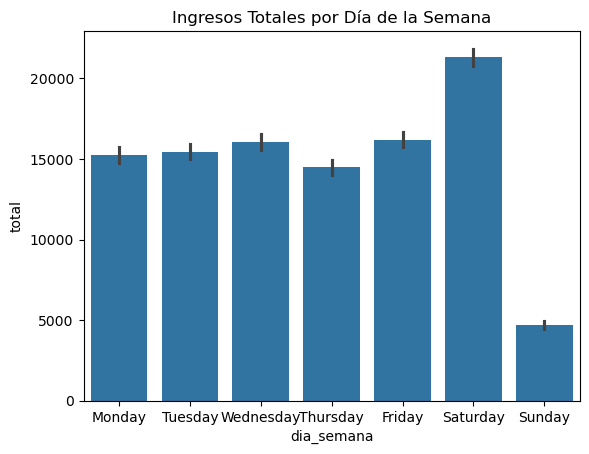

In [45]:
df['dia_semana'] = df['fecha'].dt.day_name()

# Ordenar los días correctamente
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Gráfico de barras por día de la semana
sns.barplot(data=df, x='dia_semana', y='total', order=orden_dias, estimator=sum)
plt.title('Ingresos Totales por Día de la Semana')

En el gráfico anterior se hace un resumen de los ingresos por día de la semana, destacando el sábado como día de mayor ingreso, esta observación responde a los picos del análisis anterior, estos picos corresponden el 95% a sábados  
de quincena y fin de mes, el 5% restante es un lunes 31 de agosto 2024 fin de mes. Es posible que sean ofertas intencionales en esas fechas con el fin de generar ganancias, esto será consultado con el cliente al final del EDA.

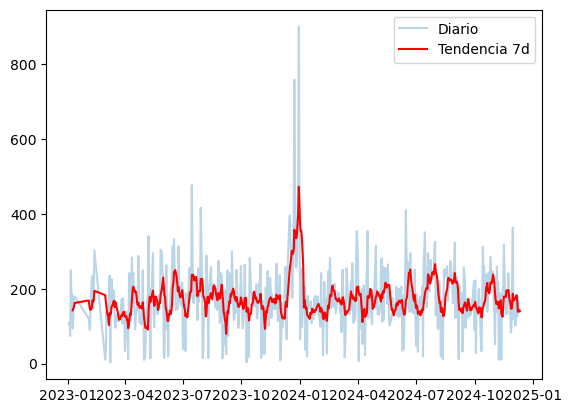

In [46]:
# Promedio móvil de 7 días (una semana)
ingreso_por_dia['promedio_7d'] = ingreso_por_dia['total'].rolling(window=7).mean()

# Graficar ambos
plt.plot(ingreso_por_dia['fecha'], ingreso_por_dia['total'], alpha=0.3, label='Diario')
plt.plot(ingreso_por_dia['fecha'], ingreso_por_dia['promedio_7d'], color='red', label='Tendencia 7d')
plt.legend()

### ¿De dónde viene el dinero? (Ingresos acumulados por categoría)

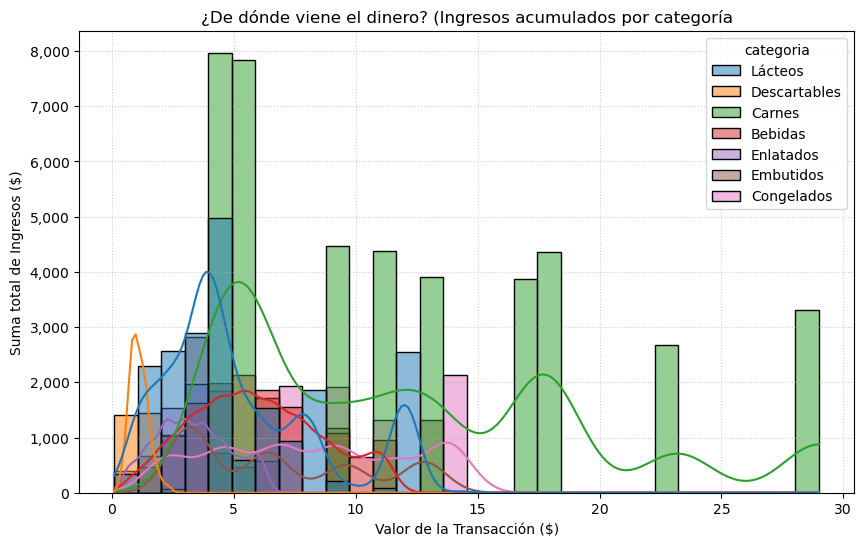

In [47]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))

# graph
ax = sns.histplot(data=df, x='total', weights=df['total'],hue = 'categoria', kde=True, color='teal', bins=30)

# 1. Formatear el eje Y para que muestre miles/millones (opcional)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 2. labeling
plt.ylabel('Suma total de Ingresos ($)') 
plt.xlabel('Valor de la Transacción ($)')
plt.title('¿De dónde viene el dinero? (Ingresos acumulados por categoría')

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

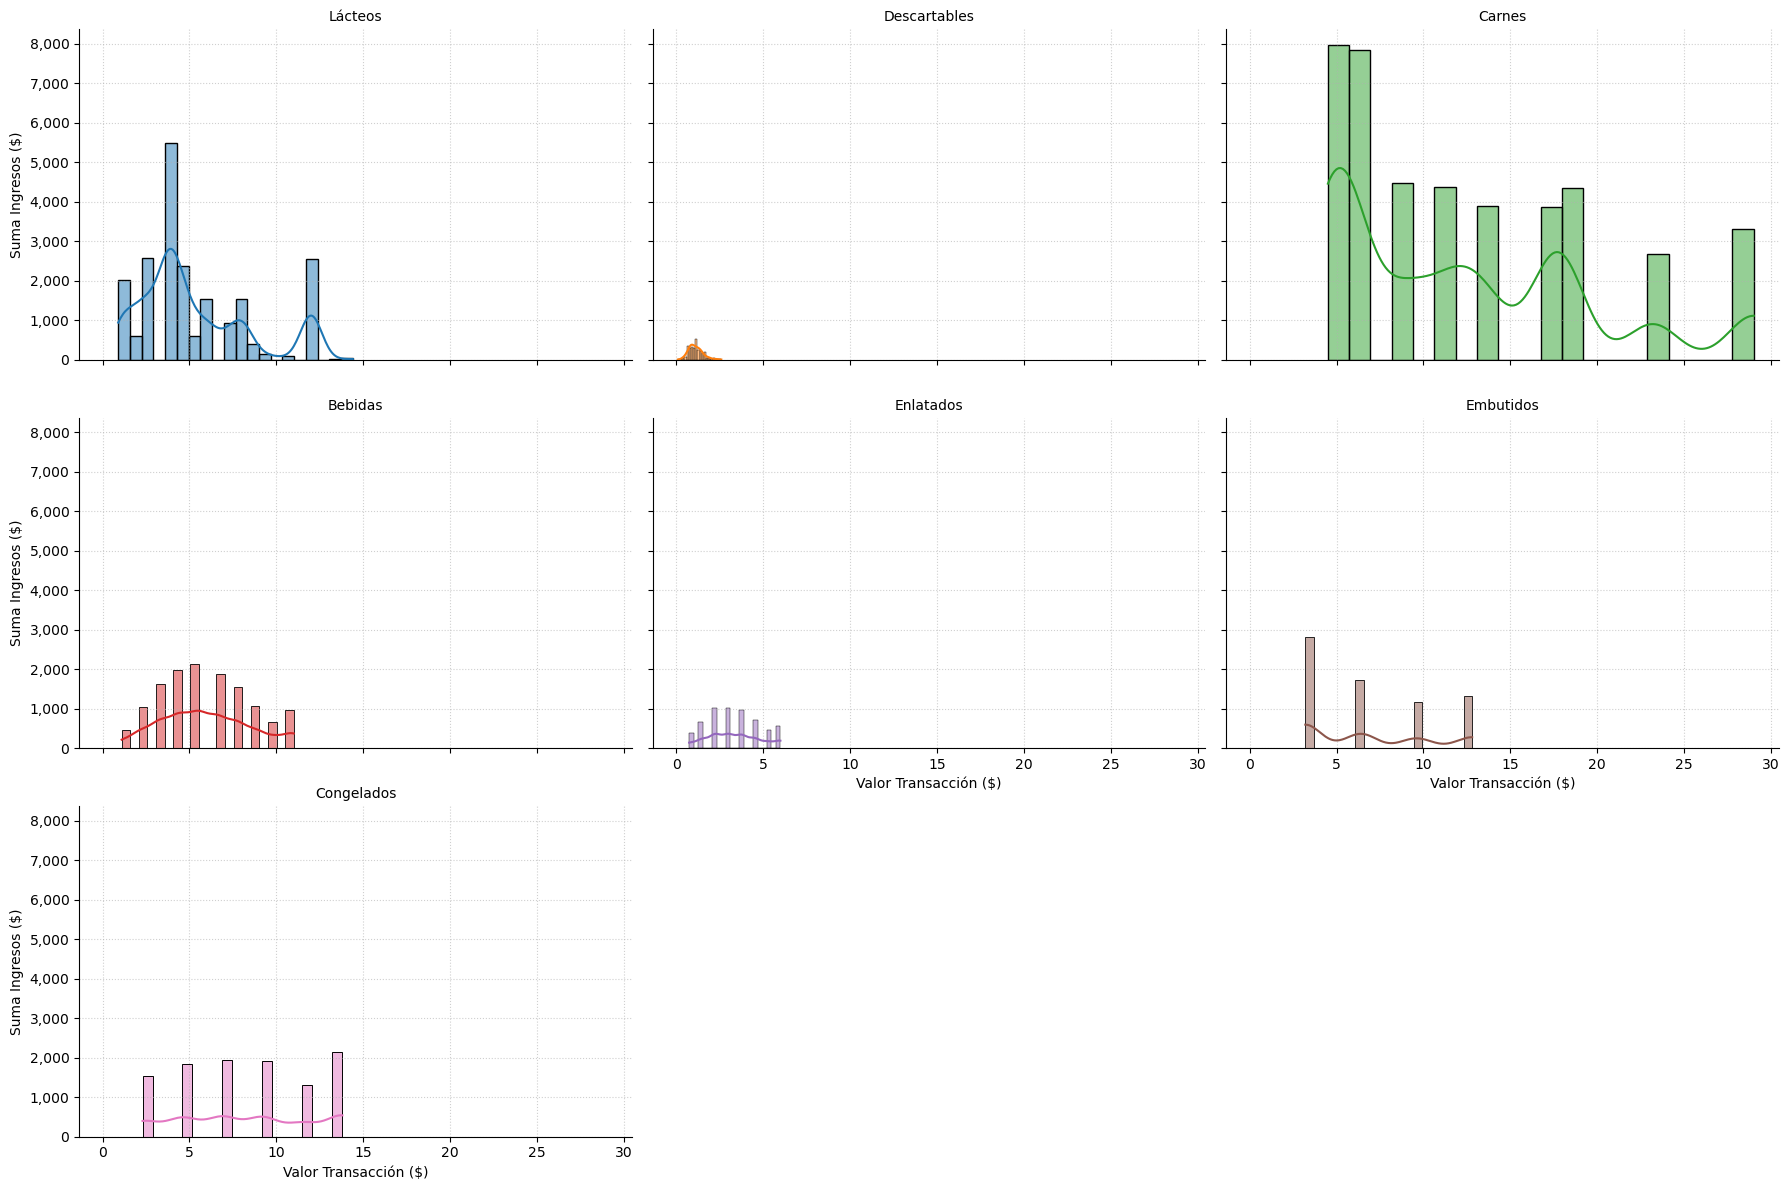

In [48]:
# Configuramos la cuadrícula: una columna para cada categoría
# col_wrap=3 significa que pondrá máximo 3 gráficos por fila
g = sns.FacetGrid(df, col="categoria", col_wrap=3, height=4, aspect=1.5, hue="categoria")

# Mapeamos el histplot a cada recuadro
g.map_dataframe(
    sns.histplot, 
    x="total", 
    weights="total", 
    kde=True, 
    bins=20
)

# Ajustes estéticos globales
g.set_axis_labels("Valor Transacción ($)", "Suma Ingresos ($)")
g.set_titles("{col_name}") # Pone el nombre de la categoría como título de cada gráfico

# Agregar cuadrícula a cada subgráfico
for ax in g.axes.flat:
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [49]:
ingresos_categorias = pd.pivot_table(df, index='categoria', values='total', aggfunc='sum')

In [50]:
ingresos_categorias.sort_values(by='total',ascending=False,inplace=True)

In [51]:
plt.figure(figsize=(8, 5))

# Histoplot
ax1 = px.bar(ingresos_categorias, y='total', text='total',
            title='Ingresos totales por categoría',
            height=500,
            color='total')

ax1.update_layout(
    coloraxis=dict(
        # Elegir la paleta de colores (Escala Continua)
        # Opciones populares: 'Cividis', 'Greens', 'Bluered', 'Hot', 'Picnic', 'Portland'
        # Ver más en: plotly.colors.sequential
        colorscale='Portland', 
        
        # Opcional: Personalizar el título de la barra de color
        colorbar=dict(title='Rango de Ingresos')
    )
)

ax1.update_traces(textposition="outside")
ax1.show()

<Figure size 800x500 with 0 Axes>

Se observa en el gráfico anterior los ingresos totales por categoría, así identificar de mayor a menor cuáles son las categorías que tienen mayor ingresos.  
(**No se contemplan lo que son las ganancias (ni netas ni brutas) ya que no es parte del alcance del proyecto.**)  
Por mucho destacan las **carnes** con respecto a las demás categorías

### Prueba para ver la relación entre columnas, dado que existen varios tipos de datos en el dataframe usaré más de un
### método para observar la relación entre ellas en este EDA, comenzando con una matriz de correlación entre las columnas numéricas:

In [52]:
df.set_index('fecha', inplace=True)

In [53]:
df.head(2)

,producto,categoria,cantidad,precio_unitario,total,metodo_pago,cantidad_log,day,month,year,dia_semana
fecha,,,,,,,,,,,
2023-05-25,Leche entera,Lácteos,4,1.2,4.8,Efectivo,1.609438,25,5,2023,Thursday
2023-08-19,Bolsas plásticas,Descartables,6,0.1,0.6,Tarjeta débito,1.945910,19,8,2023,Saturday


In [54]:
df['metodo_pago'].unique()

<StringArray>
['Efectivo', 'Tarjeta débito', 'Transferencia', 'Tarjeta crédito', 'QR']
Length: 5, dtype: str

Para efectos del proyecto se codificará la columna metodo_pago con el fin de analizar si esto influye en la cantidad de ventas y sugerir acciones al cliente:  
Efectivo('Efectivo'): 1  
Bancario ('Tarjeta crédito', 'Tarjeta débito', 'QR', 'Transferencia') : 0


In [55]:
df['metodo_pago']= df['metodo_pago'].replace(['Tarjeta crédito', 'Tarjeta débito', 'QR', 'Transferencia'],0)

In [56]:
df['metodo_pago']= df['metodo_pago'].replace(['Efectivo'],1)

In [57]:
df['metodo_pago'].unique()

array([1, 0], dtype=object)

In [58]:
df['metodo_pago'] = pd.to_numeric(df['metodo_pago'])

In [59]:
df.columns

Index(['producto', 'categoria', 'cantidad', 'precio_unitario', 'total',
       'metodo_pago', 'cantidad_log', 'day', 'month', 'year', 'dia_semana'],
      dtype='str')

Eliminamos la columna 'total' para evitar una correlación perfecta dado que esta columna es el resultado de cantidad*precio_unitario.

In [60]:
df.drop(columns='total', inplace=True)

In [61]:
df.columns

Index(['producto', 'categoria', 'cantidad', 'precio_unitario', 'metodo_pago',
       'cantidad_log', 'day', 'month', 'year', 'dia_semana'],
      dtype='str')

Eliminamos la variable 'cantidad', se usará 'cantidad_log'. (En gráficos anteriores se usó cantidad para visualización de datos reales y conocer el estado de los datos)

In [62]:
df.drop(columns='cantidad', inplace=True)

In [63]:
df.columns

Index(['producto', 'categoria', 'precio_unitario', 'metodo_pago',
       'cantidad_log', 'day', 'month', 'year', 'dia_semana'],
      dtype='str')

In [64]:
#Codificación de día de la semana a numérico:
# 1. Definir el diccionario de mapeo
mapeo_dias = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

# 2. Aplicar el mapeo a la columna
df['dia_semana'] = df['dia_semana'].map(mapeo_dias)

In [65]:
df.head()

,producto,categoria,precio_unitario,metodo_pago,cantidad_log,day,month,year,dia_semana
fecha,,,,,,,,,
2023-05-25,Leche entera,Lácteos,1.20,1,1.609438,25,5,2023,3
2023-08-19,Bolsas plásticas,Descartables,0.10,0,1.945910,19,8,2023,5
2024-12-10,Carne molida,Carnes,5.80,0,0.693147,10,12,2024,1
2023-01-11,Refresco 2L,Bebidas,1.10,1,1.386294,11,1,2023,2
2024-07-03,Pasta de Tomate,Enlatados,0.75,1,1.098612,3,7,2024,2


Veamos la matriz de correlación entre las 3 variables numéricas actuales (Incluyendo 'metodo_pago' que está codificado):

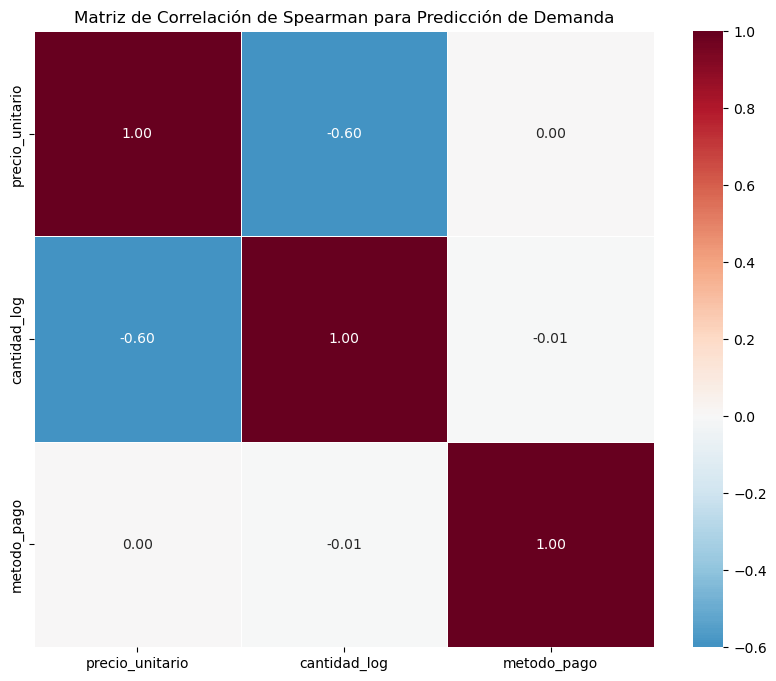

In [66]:
cols_interes = ['precio_unitario', 'cantidad_log', 'metodo_pago']
df_corr = df[cols_interes].corr(method='spearman')

# 2. Configurar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Spearman para Predicción de Demanda')
plt.show()

In [67]:
df.sort_index(inplace= True);

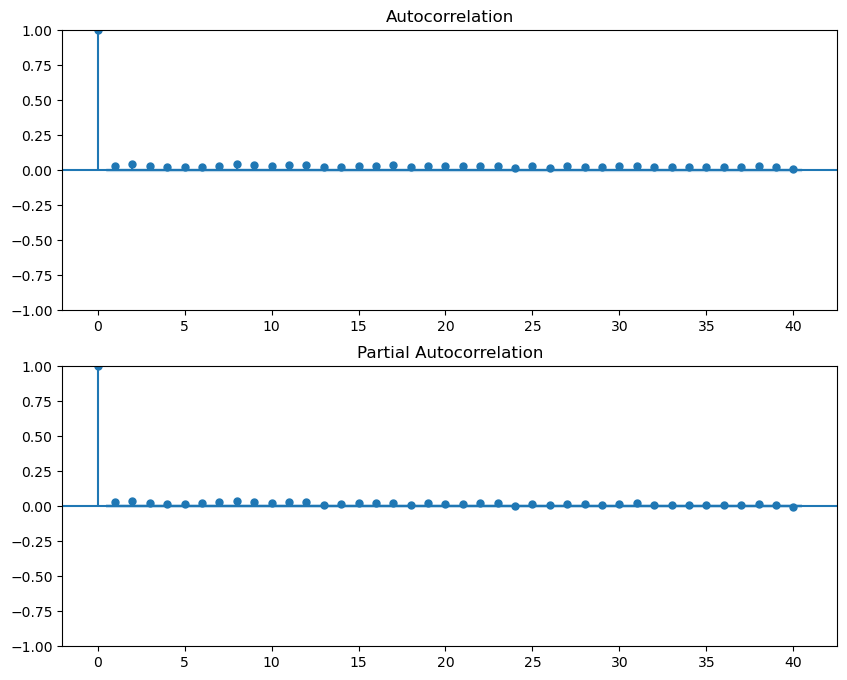

In [68]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Graficamos para ver los patrones de autocorrelación de 'cantidad_log'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df['cantidad_log'], lags=40, ax=ax2)
plt.show()

Esta falta de autocorrelación apreciada en los gráficos anteriores lo atribuyo a la mezca de todas las filas.
Las filas del df son transaccionales, es decir, no se encuentra relación entre la cantidad de venta de diferentes
categorías. Procederé a separar esto para analizarlo nuevamente.

In [69]:
df['categoria'].unique()

<StringArray>
['Descartables',      'Lácteos',    'Enlatados',       'Carnes',
    'Embutidos',      'Bebidas',   'Congelados']
Length: 7, dtype: str

### Lacteos

In [70]:
df_lacteos = df.loc[df['categoria']== 'Lácteos']

In [71]:
df_lacteos.sort_index(inplace= True);

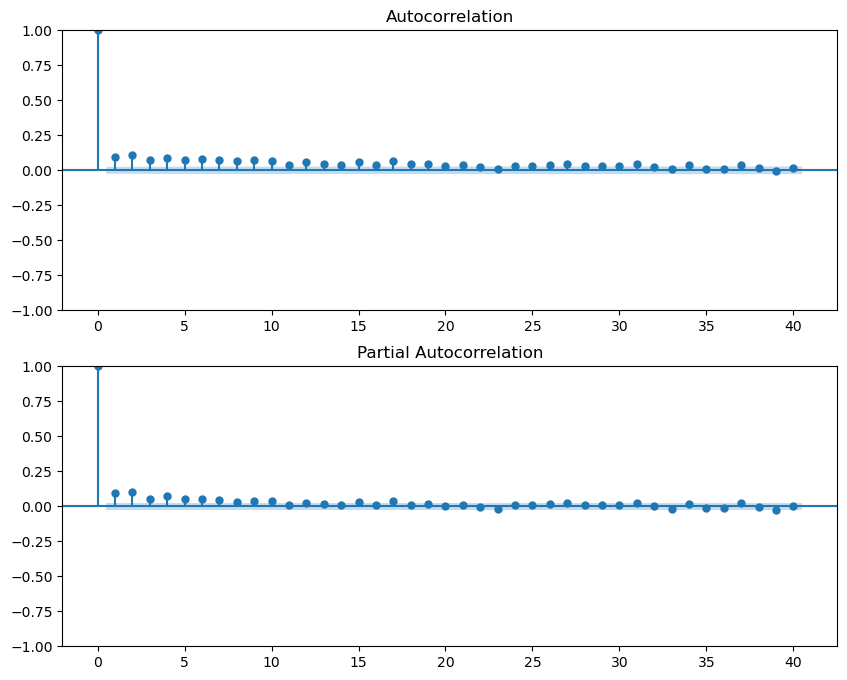

In [72]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_lacteos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_lacteos['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_lacteos['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Decartables

In [73]:
df_descartables = df.loc[df['categoria']== 'Descartables']

In [74]:
df_descartables.sort_index(inplace= True);

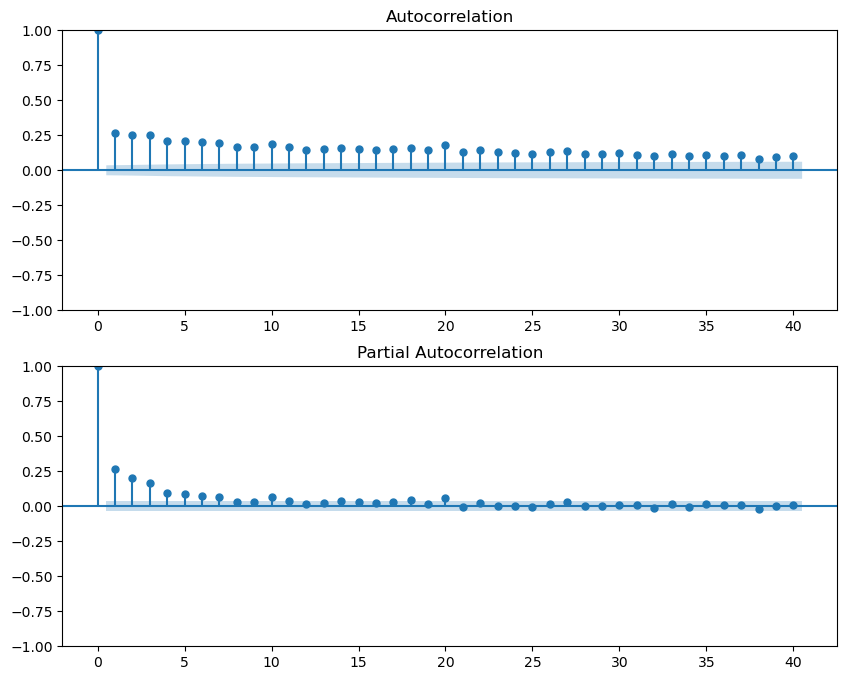

In [75]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_descartables
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_descartables['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_descartables['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Carnes

In [76]:
df_carnes = df.loc[df['categoria']== 'Carnes']

In [77]:
df_carnes.sort_index(inplace= True);

In [78]:
print(df_carnes.index.is_monotonic_increasing)

True


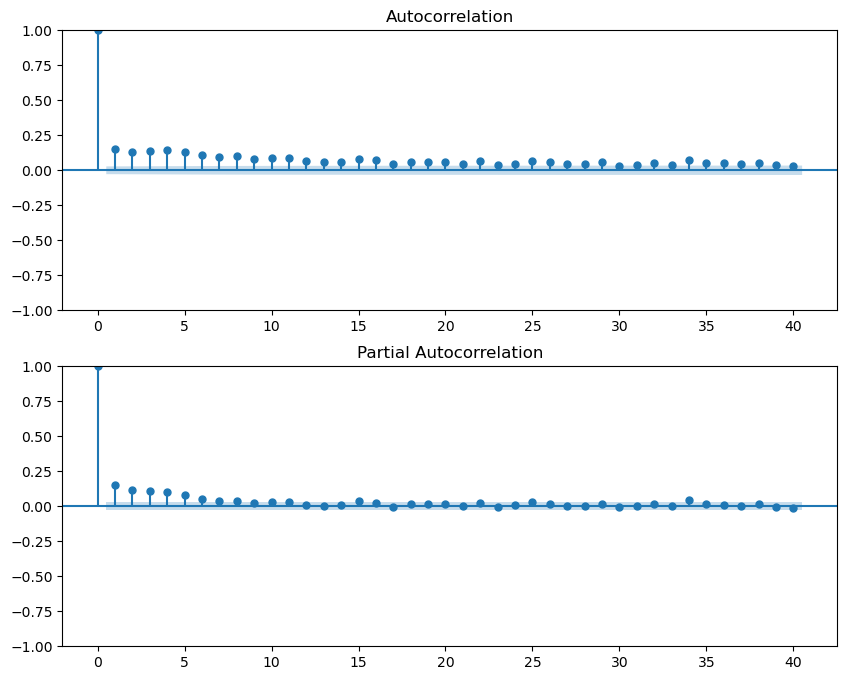

In [79]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en Carnes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_carnes['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_carnes['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Bebidas

In [80]:
df_bebidas = df.loc[df['categoria']== 'Bebidas']

In [81]:
df_bebidas.sort_index(inplace= True);

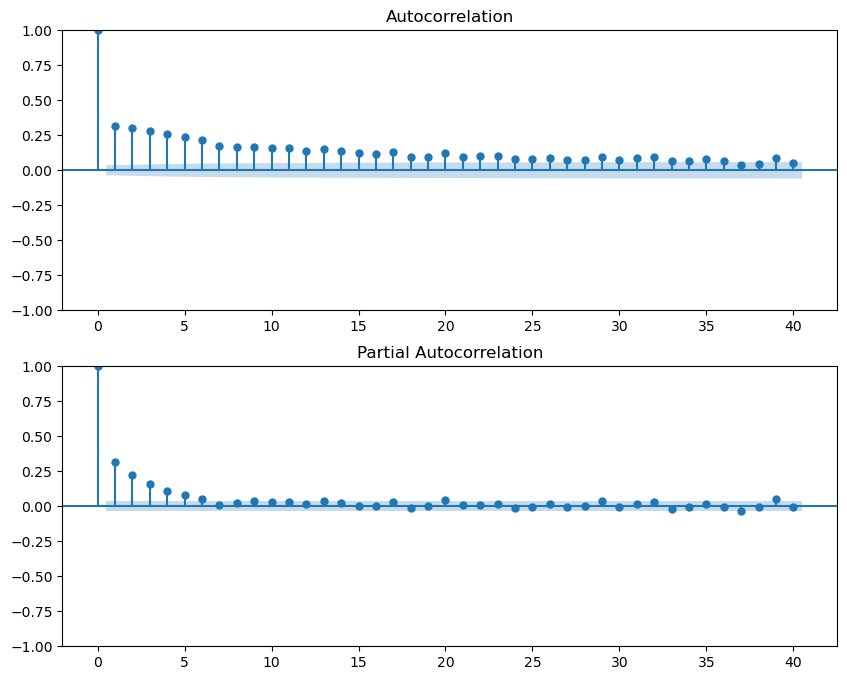

In [82]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_bebidas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_bebidas['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_bebidas['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Enlatados

In [83]:
df_enlatados = df.loc[df['categoria']== 'Enlatados']

In [84]:
df_enlatados.sort_index(inplace= True);

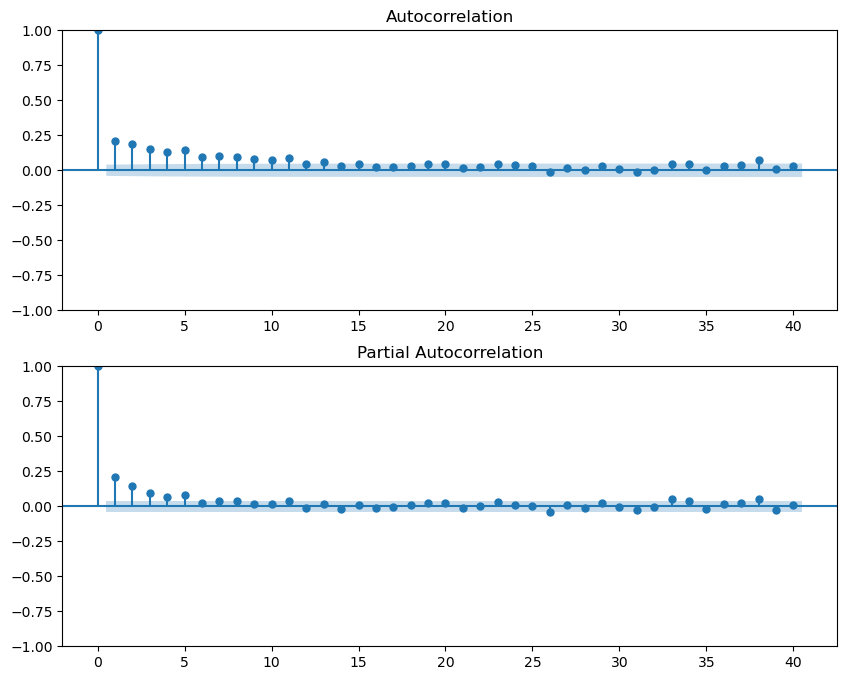

In [85]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_enlatados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_enlatados['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_enlatados['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Embutidos

In [86]:
df_embutidos = df.loc[df['categoria']== 'Embutidos']

In [87]:
df_embutidos.sort_index(inplace= True);

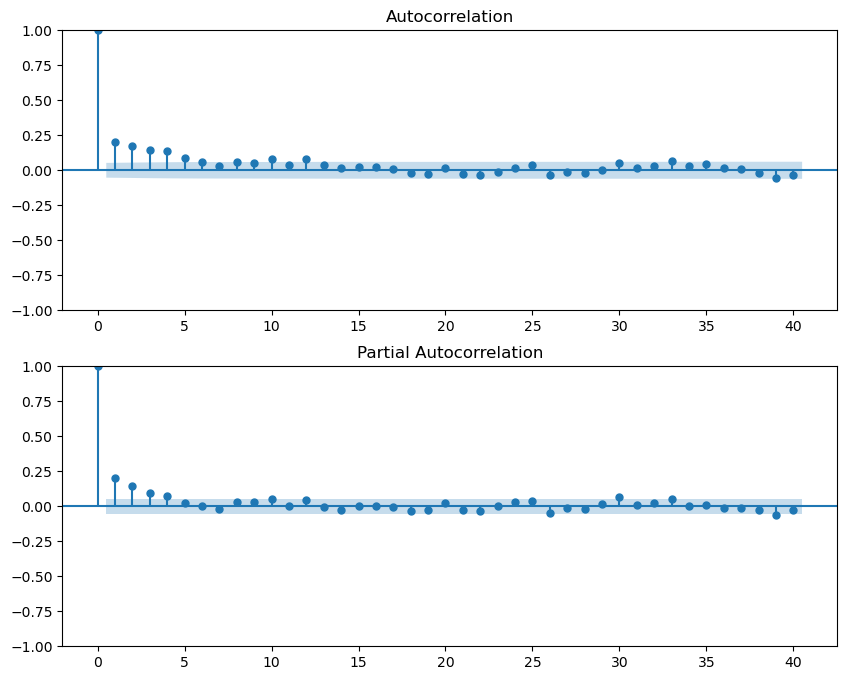

In [88]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_embutidos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_embutidos['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_embutidos['cantidad_log'], lags=40, ax=ax2)
plt.show()

### Congelados

In [89]:
df_congelados = df.loc[df['categoria']== 'Congelados']

In [90]:
df_congelados.sort_index(inplace= True);

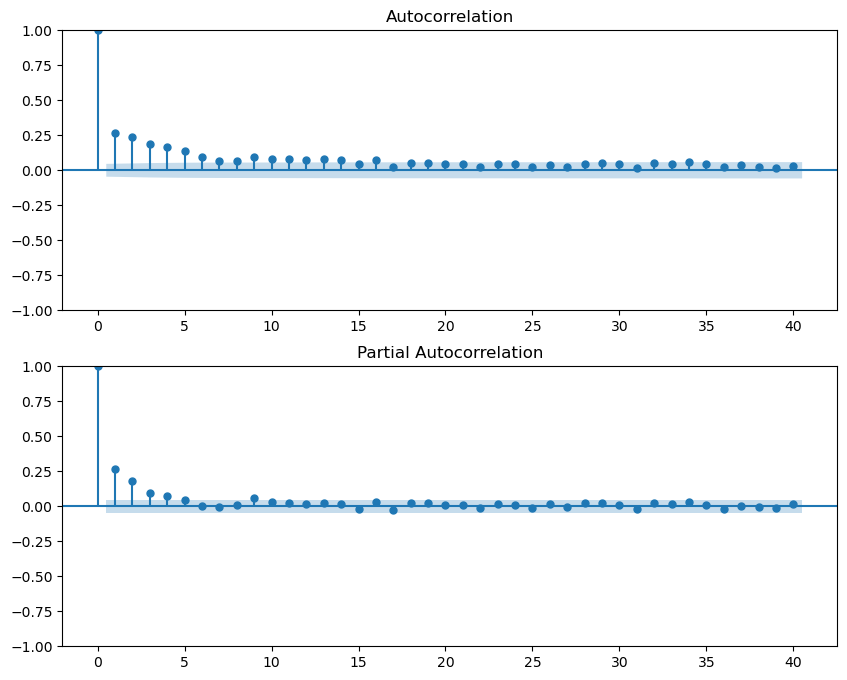

In [91]:
# Graficamos para ver los patrones de autocorrelación de 'cantidad_log' en df_congelados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_congelados['cantidad_log'], lags=40, ax=ax1)
plot_pacf(df_congelados['cantidad_log'], lags=40, ax=ax2)
plt.show()

Después de separar por categoría entonces vemos la existencia de cierta autocorrelación en la variable cantidad_log para cada una.
Después de esto se decide que se considera aplicar un modelo ARIMA o ARIMAX para el forecasting horizontal.

In [92]:
from statsmodels.tsa.stattools import ccf

In [93]:
#Crearé un diccionario de DataFrames
dfs = {'Lacteos': df_lacteos,
       'Descartables': df_descartables,
       'Carnes' : df_carnes,
       'Bebidas' : df_bebidas,
       'Enlatados' : df_enlatados,
       'Embutidos' : df_embutidos,
       'Congelados': df_congelados
      }

In [94]:
df_lacteos

,producto,categoria,precio_unitario,metodo_pago,cantidad_log,day,month,year,dia_semana
fecha,,,,,,,,,
2023-01-03,Yogurt natural,Lácteos,0.9,1,1.791759,3,1,2023,1
2023-01-03,Helado familiar,Lácteos,4.0,0,0.693147,3,1,2023,1
2023-01-03,Leche entera,Lácteos,1.2,1,0.693147,3,1,2023,1
2023-01-03,Leche entera,Lácteos,1.2,0,1.386294,3,1,2023,1
2023-01-03,Helado familiar,Lácteos,4.0,0,0.693147,3,1,2023,1
...,...,...,...,...,...,...,...,...,...
2024-12-11,Helado familiar,Lácteos,4.0,0,0.693147,11,12,2024,2
2024-12-11,Yogurt natural,Lácteos,0.9,0,1.098612,11,12,2024,2
2024-12-11,Helado familiar,Lácteos,4.0,0,0.693147,11,12,2024,2



--- Análisis de variables: Lacteos ---


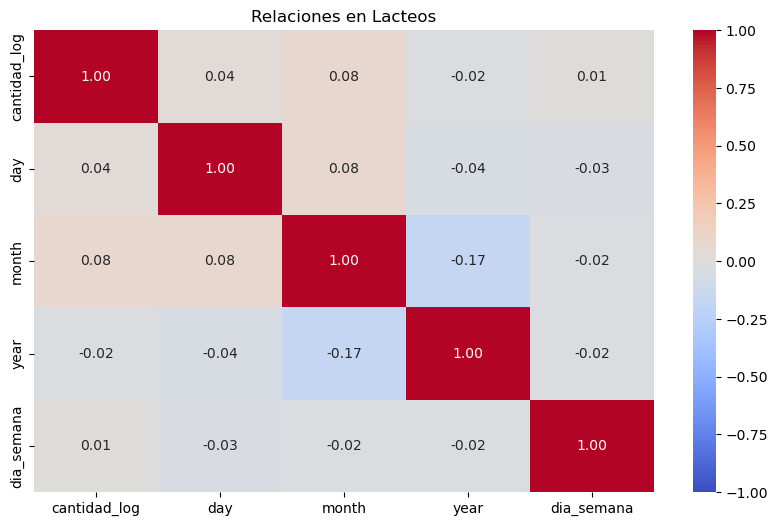


--- Análisis de variables: Descartables ---


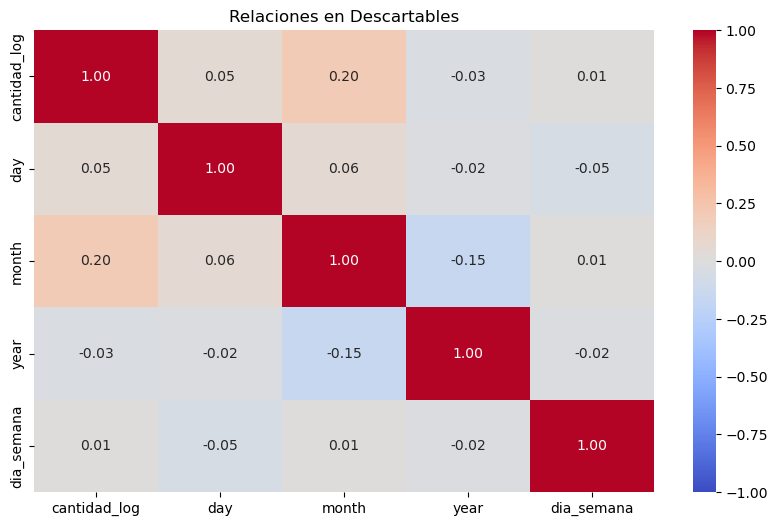


--- Análisis de variables: Carnes ---


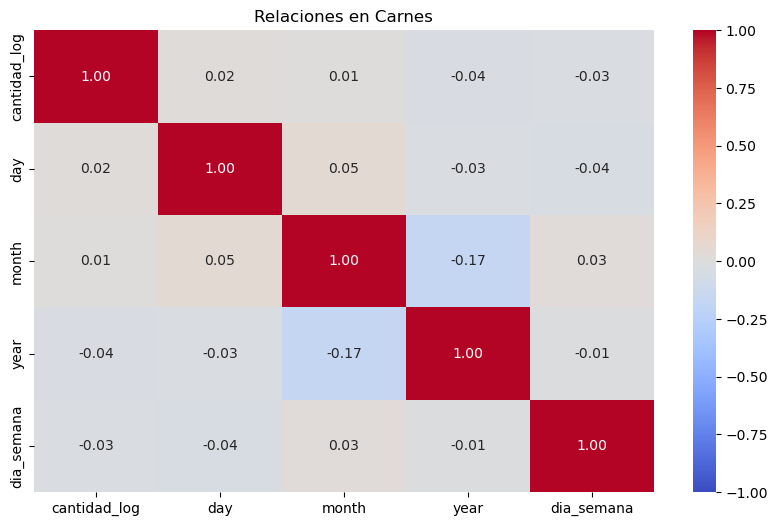


--- Análisis de variables: Bebidas ---


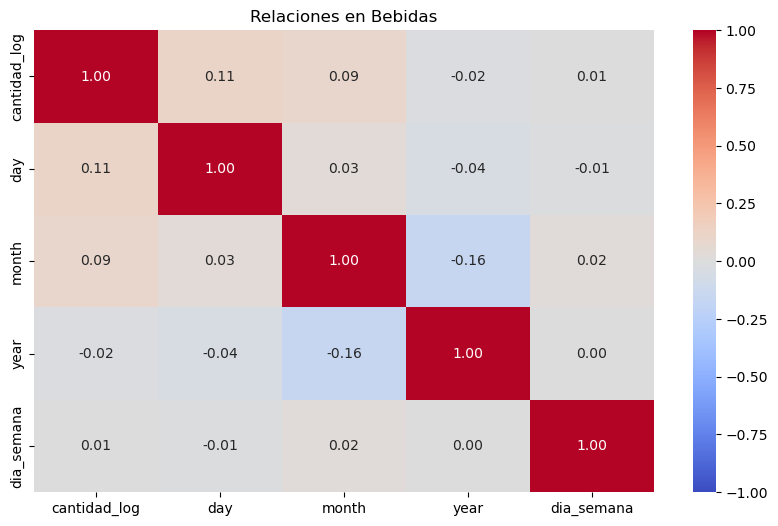


--- Análisis de variables: Enlatados ---


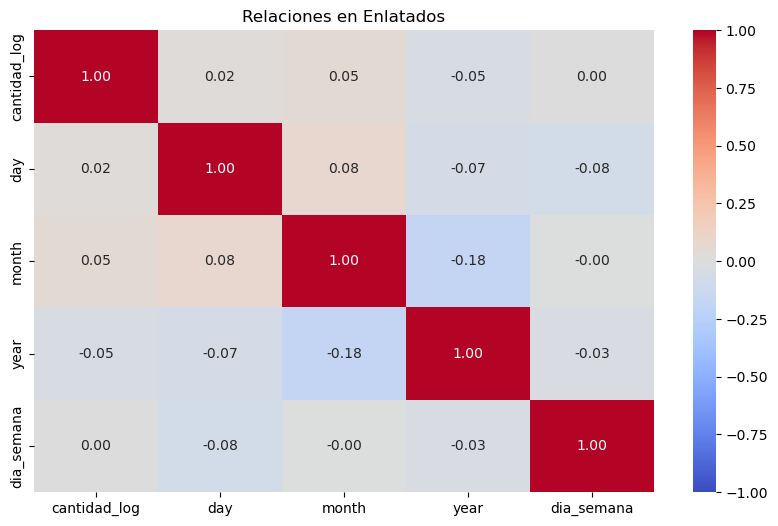


--- Análisis de variables: Embutidos ---


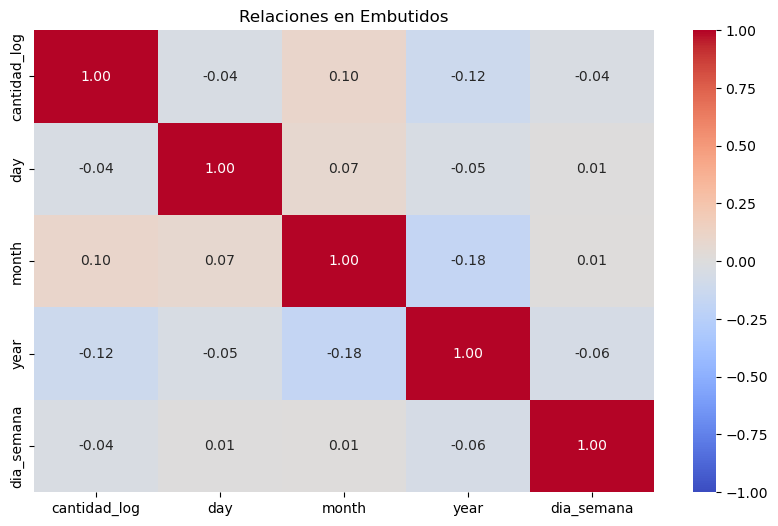


--- Análisis de variables: Congelados ---


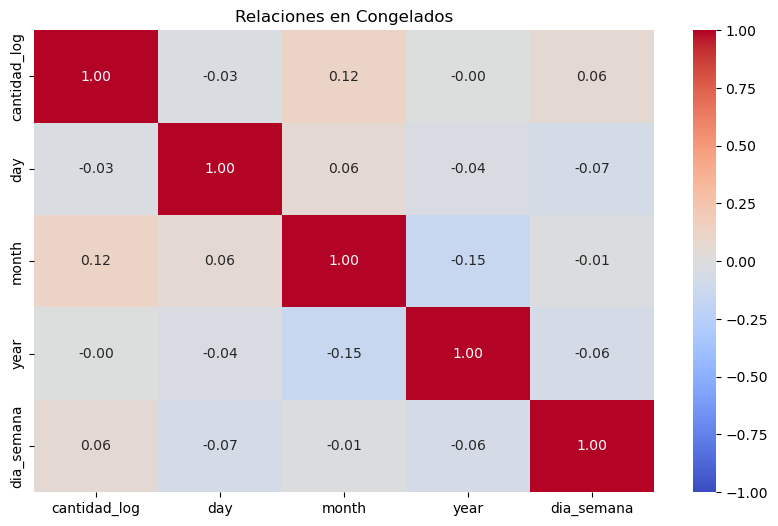

In [95]:
# Lista de variables a analizar
cols_analisis = ['cantidad_log', 'day', 'month', 'year', 'dia_semana']

for cat, df in dfs.items():
    print(f"\n--- Análisis de variables: {cat} ---")
    
    # Obtenemos solo las columnas que empiezan con 'pago_'
    cols_pago = [col for col in df.columns if col.startswith('pago_')]
    
    # Combinamos todo para la matriz
    df_subset = df[cols_analisis + cols_pago]
    
    # Matriz de Correlación
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title(f'Relaciones en {cat}')
    plt.show()

Vemos relaciones realmente no significantes en los datos con respecto a la variable objetivo que es 'cantidad_log'. Se refuerza la consideración de usar un modelo ARIMA.


--- Descomposición de la serie: Lacteos ---


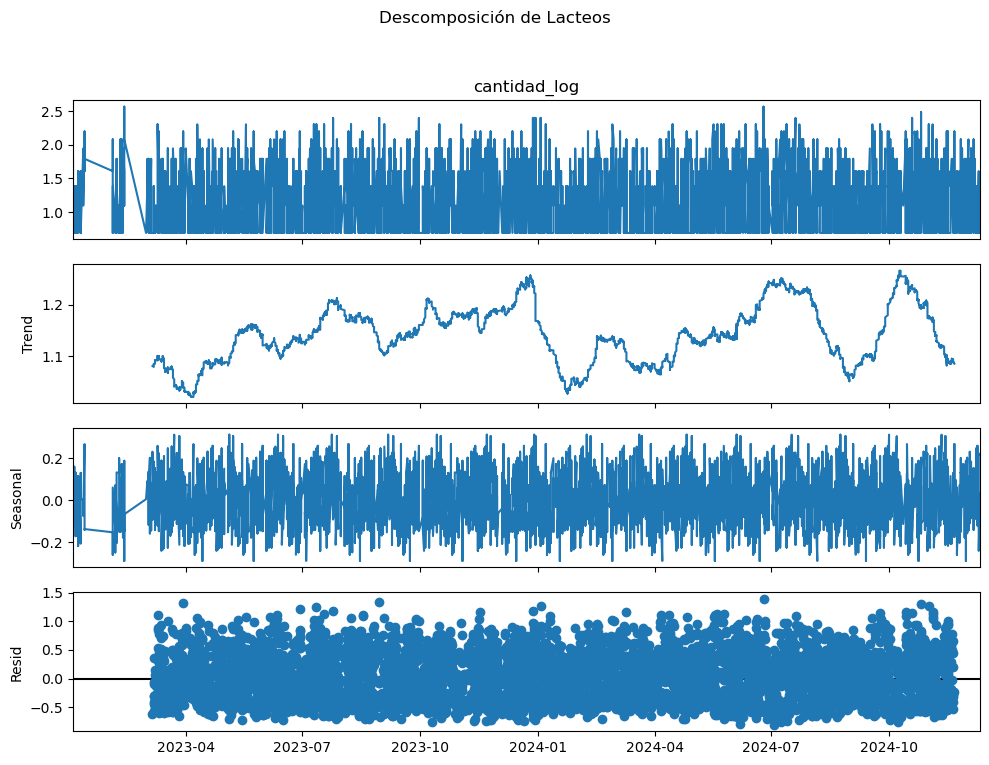


--- Descomposición de la serie: Descartables ---


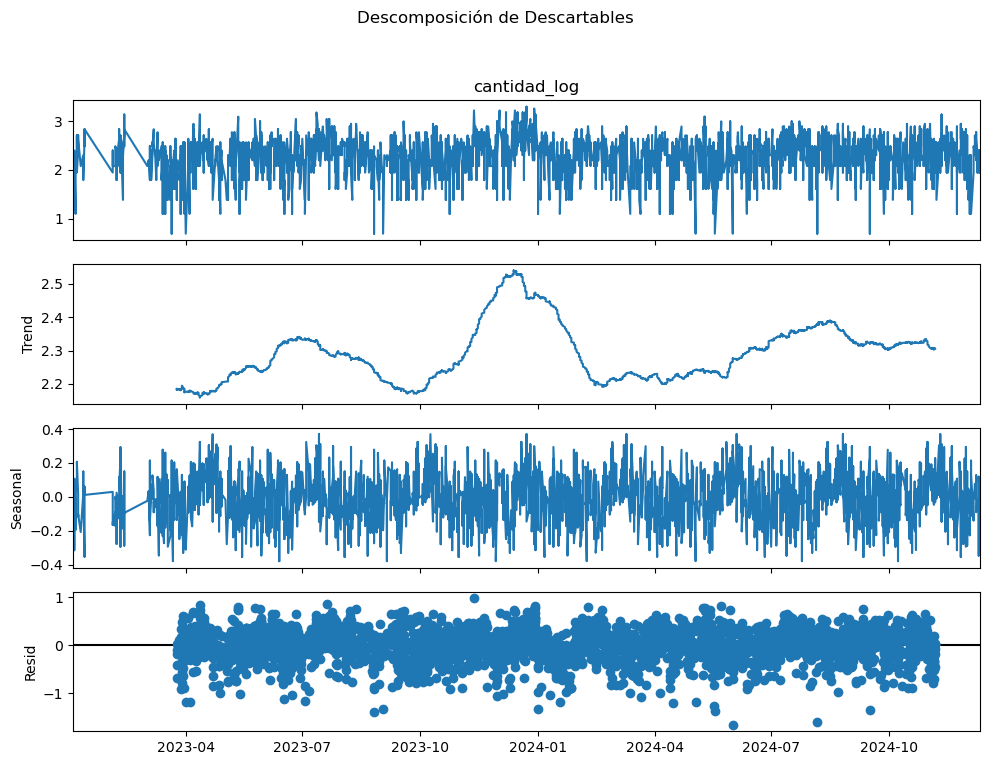


--- Descomposición de la serie: Carnes ---


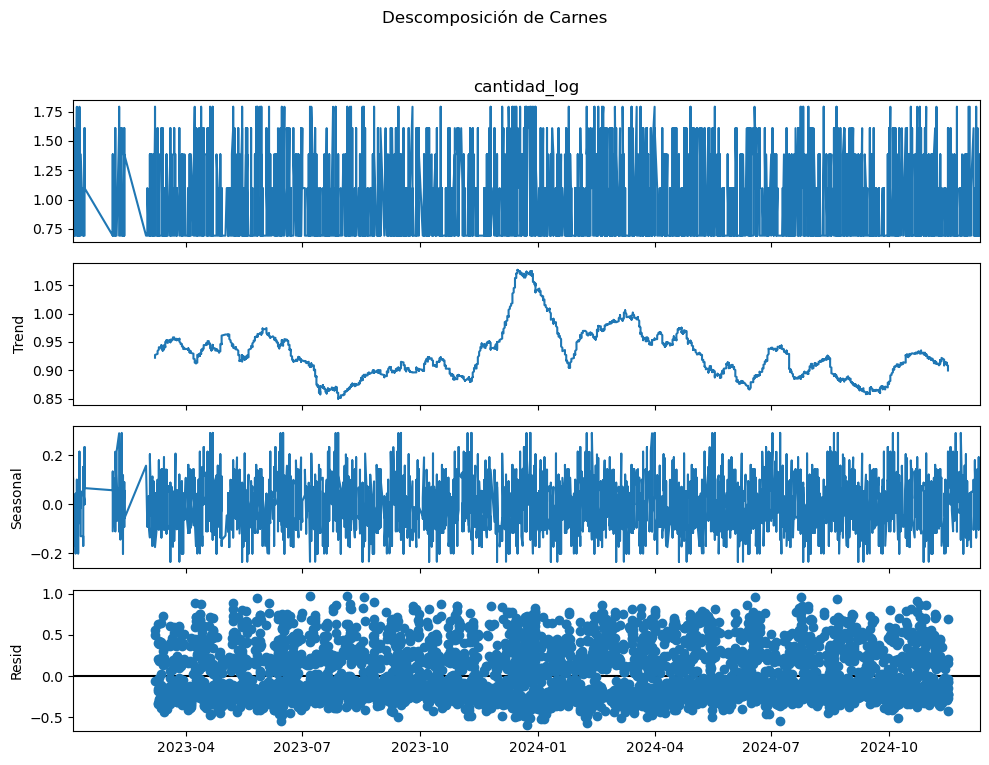


--- Descomposición de la serie: Bebidas ---


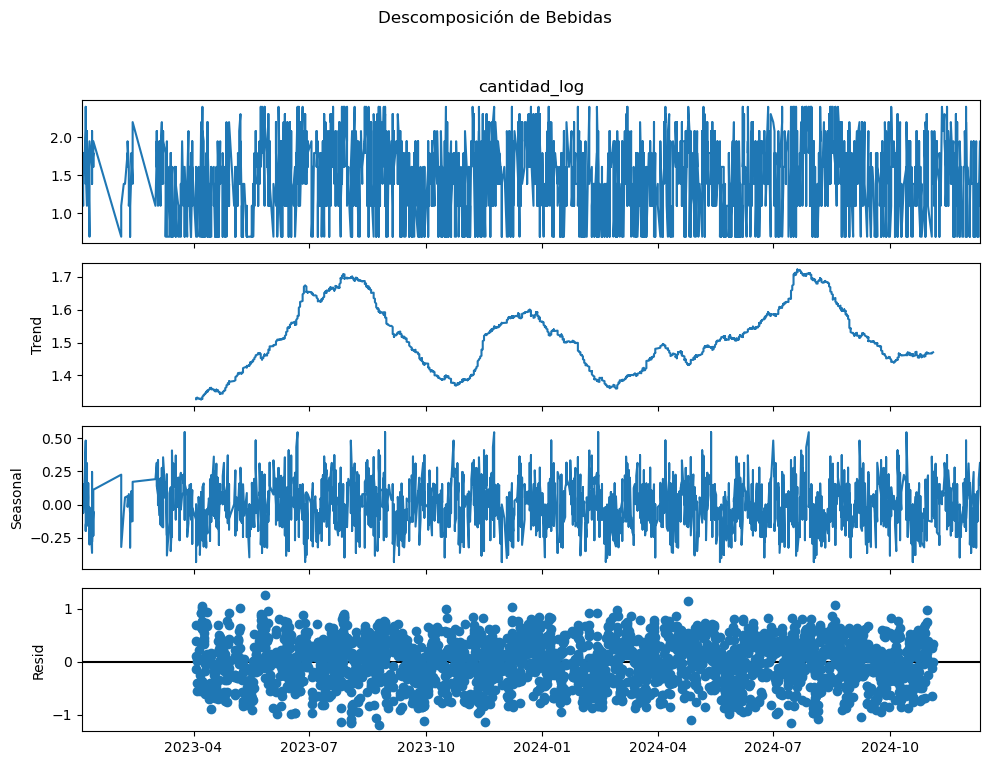


--- Descomposición de la serie: Enlatados ---


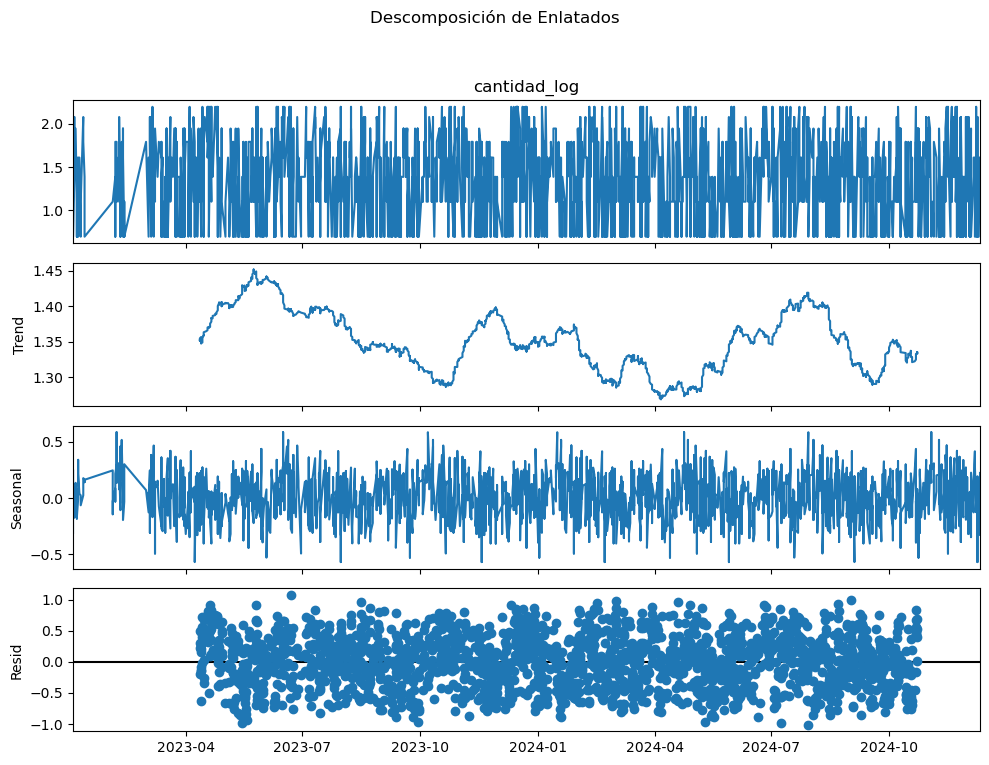


--- Descomposición de la serie: Embutidos ---


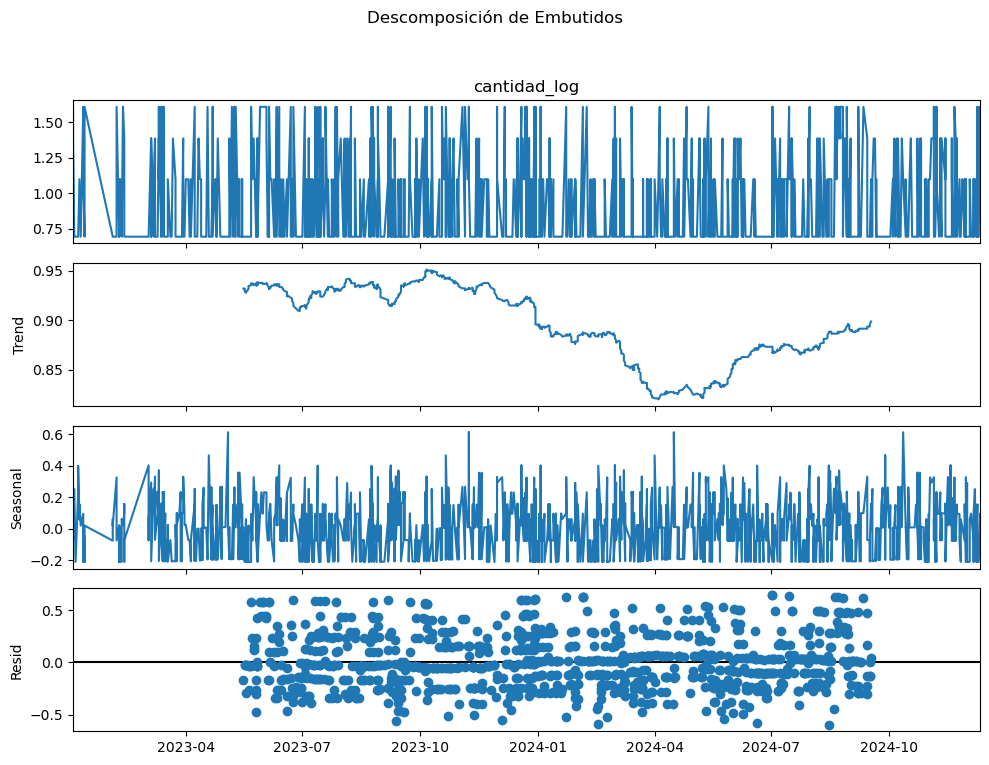


--- Descomposición de la serie: Congelados ---


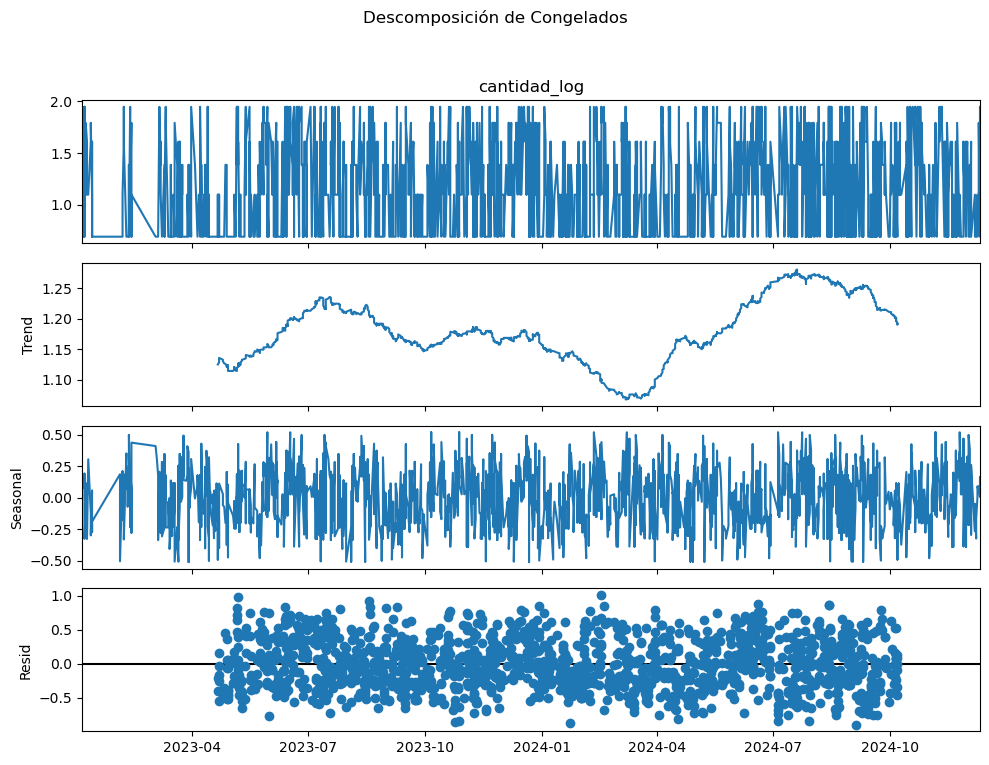

In [96]:
from statsmodels.tsa.seasonal import seasonal_decompose

for cat, df in dfs.items():
    print(f"\n--- Descomposición de la serie: {cat} ---")
    
    # Es vital usar la frecuencia. Si tus datos son diarios, usamos period=7 (semanal) o 30 (mensual)
    # Ajusta 'period' según el ciclo que esperes ver (ej: 7 para estacionalidad semanal)
    resultado = seasonal_decompose(df['cantidad_log'], model='additive', period=365)
    
    fig = resultado.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(f'Descomposición de {cat}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [97]:
from statsmodels.tsa.stattools import adfuller

def test_estacionariedad(timeseries):
    # Ejecutar prueba ADF
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nResultado: La serie es ESTACIONARIA (p-value < 0.05)")
    else:
        print("\nResultado: La serie NO es estacionaria (p-value >= 0.05). Necesita diferenciación.")

# Ejecutar la prueba para cada categoría
for cat, df in dfs.items():
    print(f"\n--- Prueba ADF para: {cat} ---")
    test_estacionariedad(df['cantidad_log'])


--- Prueba ADF para: Lacteos ---
Test Statistic                -1.386076e+01
p-value                        6.736261e-26
#Lags Used                     1.600000e+01
Number of Observations Used    6.061000e+03
dtype: float64

Resultado: La serie es ESTACIONARIA (p-value < 0.05)

--- Prueba ADF para: Descartables ---
Test Statistic                -6.606080e+00
p-value                        6.551643e-09
#Lags Used                     1.900000e+01
Number of Observations Used    3.008000e+03
dtype: float64

Resultado: La serie es ESTACIONARIA (p-value < 0.05)

--- Prueba ADF para: Carnes ---
Test Statistic                -1.247105e+01
p-value                        3.244341e-23
#Lags Used                     1.500000e+01
Number of Observations Used    4.963000e+03
dtype: float64

Resultado: La serie es ESTACIONARIA (p-value < 0.05)

--- Prueba ADF para: Bebidas ---
Test Statistic                -9.522131e+00
p-value                        3.044896e-16
#Lags Used                     1.2000

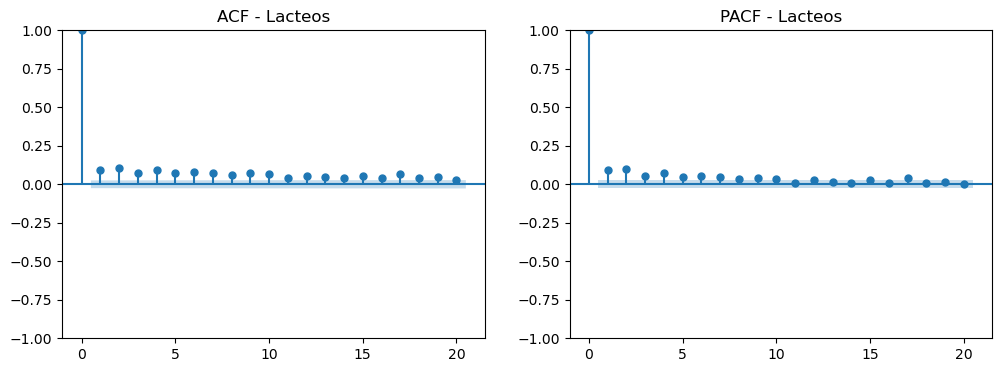

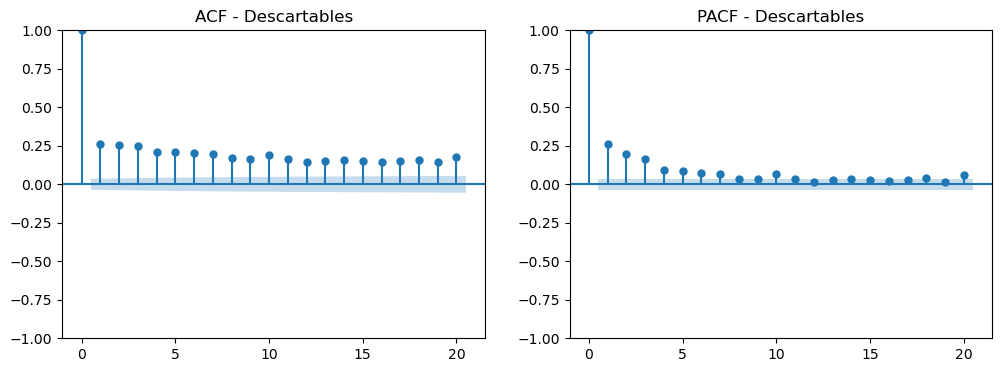

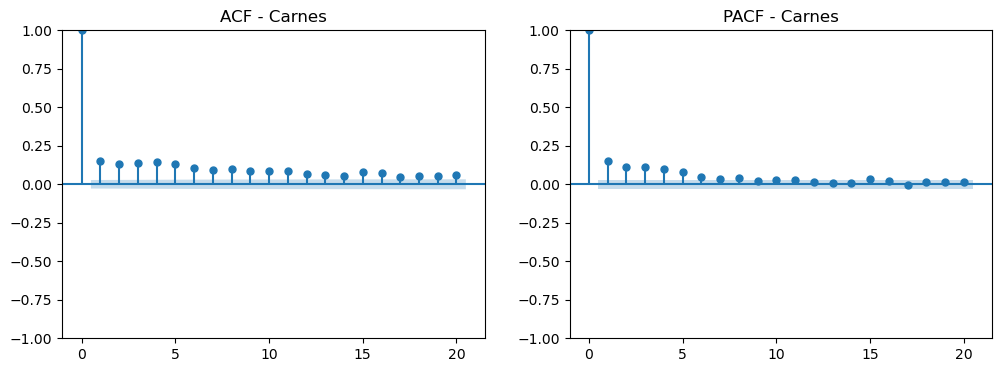

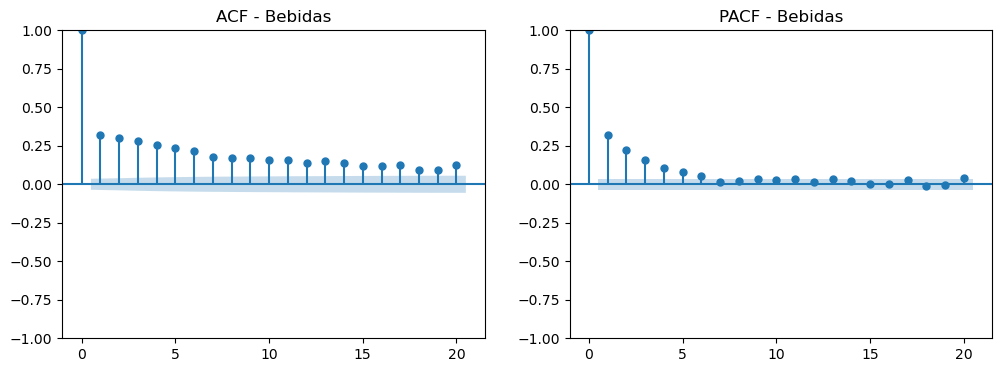

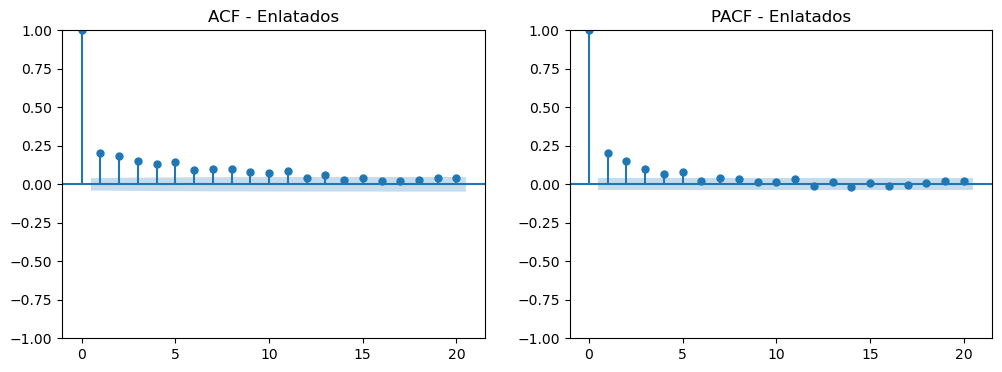

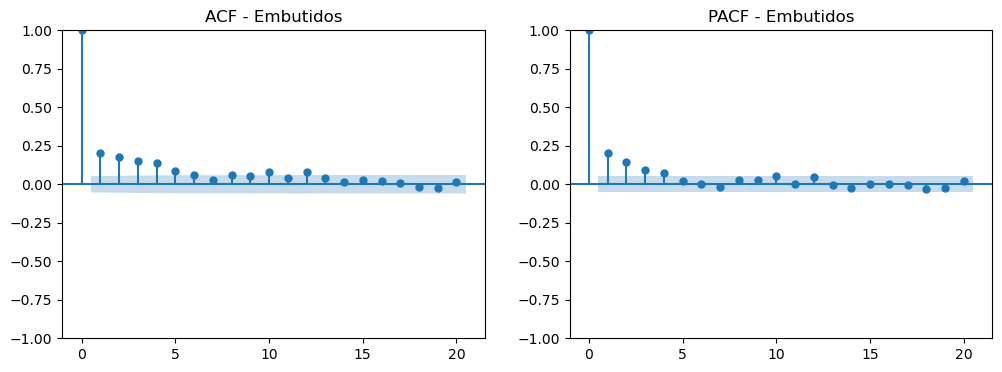

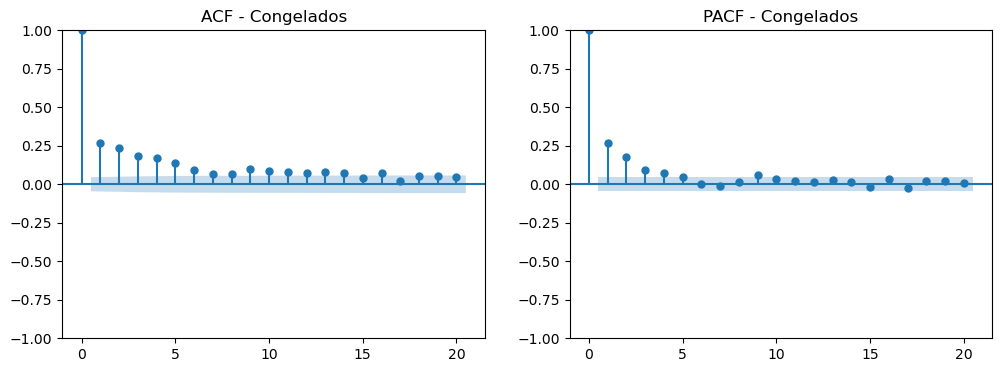

In [98]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for cat, df in dfs.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # ACF para identificar q
    plot_acf(df['cantidad_log'], ax=ax1, lags=20)
    ax1.set_title(f'ACF - {cat}')
    
    # PACF para identificar p
    plot_pacf(df['cantidad_log'], ax=ax2, lags=20)
    ax2.set_title(f'PACF - {cat}')
    
    plt.show()

In [99]:


# Diccionario para guardar los modelos entrenados
modelos = {}
predicciones = {}

'''for cat, df in dfs.items():
    print(f"\n--- Entrenando modelo para: {cat} ---")
    
    # auto_arima busca automáticamente los mejores p, d, q
    # d=0 porque ya confirmaste que son estacionarias
    # seasonal=True si quieres que el modelo capture el ciclo semanal (s=7)
    model = pm.auto_arima(df['cantidad_log'], 
                          start_p=0, start_q=0,
                          max_p=3, max_q=3,
                          d=0,             # Ya confirmado por ADF
                          seasonal=True,   # Recomendado por gráficos
                          m=7,             # Estacionalidad semanal
                          trace=True,      # Para ver el progreso
                          error_action='ignore',  
                          suppress_warnings=True)
    
    modelos[cat] = model
    
    # Predecir 90 días (3 meses)
    forecast = model.predict(n_periods=90)
    predicciones[cat] = forecast
    print(f"Modelo para {cat} finalizado.")
'
# Ahora 'predicciones' tiene tus resultados para los próximos 3 meses'''

'for cat, df in dfs.items():\n    print(f"\n--- Entrenando modelo para: {cat} ---")\n\n    # auto_arima busca automáticamente los mejores p, d, q\n    # d=0 porque ya confirmaste que son estacionarias\n    # seasonal=True si quieres que el modelo capture el ciclo semanal (s=7)\n    model = pm.auto_arima(df[\'cantidad_log\'], \n                          start_p=0, start_q=0,\n                          max_p=3, max_q=3,\n                          d=0,             # Ya confirmado por ADF\n                          seasonal=True,   # Recomendado por gráficos\n                          m=7,             # Estacionalidad semanal\n                          trace=True,      # Para ver el progreso\n                          error_action=\'ignore\',  \n                          suppress_warnings=True)\n\n    modelos[cat] = model\n\n    # Predecir 90 días (3 meses)\n    forecast = model.predict(n_periods=90)\n    predicciones[cat] = forecast\n    print(f"Modelo para {cat} finalizado.")\n\'\n# Ahor

In [100]:
modelos 

{}

In [101]:
savingModels= '''{'Lacteos': ARIMA(order=(2, 0, 2), scoring_args={}, seasonal_order=(0, 0, 0, 7),
       suppress_warnings=True),
 'Descartables': ARIMA(order=(2, 0, 2), scoring_args={}, seasonal_order=(2, 0, 0, 7),
       suppress_warnings=True),
 'Carnes': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(0, 0, 0, 7),
       suppress_warnings=True),
 'Bebidas': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 0, 7),
       suppress_warnings=True),
 'Enlatados': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(0, 0, 0, 7),
       suppress_warnings=True),
 'Embutidos': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(0, 0, 1, 7),
       suppress_warnings=True),
 'Congelados': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 0, 7),
       suppress_warnings=True)}'''

In [102]:
# Corrección del Diccionario: Agrupar por día
for cat, df in dfs.items():
    # Sumamos las cantidades diarias y promediamos los otros valores numéricos
    dfs[cat] = df.resample('D').agg({'cantidad_log': 'sum'}).fillna(0)

In [103]:
import pmdarima as pm

modelos = {}

for cat, df in dfs.items():
    # Separación: Todo menos los últimos 90 días para entrenar
    train = df['cantidad_log'][:-90]
    test = df['cantidad_log'][-90:]
    
    print(f"\n--- Entrenando modelo para: {cat} ---")
    model = pm.auto_arima(train, 
                          d=0, 
                          seasonal=True, 
                          m=7, 
                          trace=True)
    
    modelos[cat] = model


--- Entrenando modelo para: Lacteos ---
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.24 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=4184.391, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4099.985, Time=0.45 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=4117.456, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=4831.415, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=4179.582, Time=0.14 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=4095.423, Time=1.24 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=4045.519, Time=3.14 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=4044.937, Time=1.30 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=4116.745, Time=0.46 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=4038.203, Time=2.94 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=4105.596, Time=0.91 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=4452.158, Time=1.72 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=4052.770, Time=2.92 s

In [108]:
modelos

{'Lacteos': ARIMA(order=(2, 0, 0), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Descartables': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Carnes': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True),
 'Bebidas': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Enlatados': ARIMA(order=(0, 0, 2), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True),
 'Embutidos': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(2, 0, 0, 7),
       suppress_warnings=True),
 'Congelados': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True)}

In [109]:
savingModels2= '''{'Lacteos': ARIMA(order=(2, 0, 0), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Descartables': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Carnes': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True),
 'Bebidas': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(1, 0, 2, 7),
       suppress_warnings=True),
 'Enlatados': ARIMA(order=(0, 0, 2), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True),
 'Embutidos': ARIMA(order=(1, 0, 1), scoring_args={}, seasonal_order=(2, 0, 0, 7),
       suppress_warnings=True),
 'Congelados': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
       suppress_warnings=True)}'''

In [110]:
print(df['cantidad_log'].describe())

count    708.000000
mean       3.015735
std        2.737562
min        0.000000
25%        0.693147
50%        2.484907
75%        4.840219
max       19.807163
Name: cantidad_log, dtype: float64


In [111]:
import pmdarima as pm
import numpy as np
import pandas as pd
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominador != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominador[mask]) * 100

mejores_modelos = {}
registros = []

for cat in CATEGORIAS:
    y_train = train_dict[cat]['cantidad_log'].values
    y_test  = test_dict[cat]['cantidad_log'].values

    print(f"Entrenando {cat}...", end=' ')

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pm.auto_arima(
            y_train,
            seasonal=False,          # ARIMA puro, sin estacionalidad
            d=None,                  # que detecte automáticamente si necesita diferenciación
            start_p=0, max_p=5,
            start_q=0, max_q=5,
            information_criterion='aic',
            stepwise=True,
            out_of_sample_size=28,
            scoring='mse',
            error_action='ignore',
            suppress_warnings=True,
        )

    n_test = len(y_test)
    pred_test, ci = fit.predict(n_periods=n_test, return_conf_int=True)

    rmse_log  = np.sqrt(mean_squared_error(y_test, pred_test))
    mae_orig  = mean_absolute_error(np.expm1(y_test), np.expm1(pred_test))
    smape_val = smape(y_test, pred_test)

    mejores_modelos[cat] = fit
    registros.append({
        'Categoría':      cat,
        'Orden ARIMA':    fit.order,
        'AIC':            round(fit.aic(), 2),
        'RMSE (log)':     round(rmse_log, 4),
        'MAE (unidades)': round(mae_orig, 2),
        'SMAPE (%)':      round(smape_val, 2),
    })
    print(f"orden={fit.order}  SMAPE={smape_val:.1f}%  MAE={mae_orig:.1f} unidades")

metricas_df = pd.DataFrame(registros).set_index('Categoría')

display(
    metricas_df.style
    .map(lambda v: (
        'background-color:#d4edda' if v < 25 else
        'background-color:#fff3cd' if v < 40 else
        'background-color:#f8d7da'
    ), subset=['SMAPE (%)'])
    .format({
        'AIC':            '{:.2f}',
        'RMSE (log)':     '{:.4f}',
        'MAE (unidades)': '{:.1f}',
        'SMAPE (%)':      '{:.2f}%'
    })
    .set_caption('ARIMA — Métricas con SMAPE robusto a ceros')
)

NameError: name 'CATEGORIAS' is not defined

In [112]:
# Diagnóstico completo de la variable target
for cat in CATEGORIAS:
    y_log   = train_dict[cat]['cantidad_log'].values
    y_orig  = train_dict[cat]['cantidad'].values
    y_back  = np.expm1(y_log)

    print(f"\n{'='*55}")
    print(f"  {cat}")
    print(f"  cantidad_log  → min: {y_log.min():.3f}  max: {y_log.max():.3f}  media: {y_log.mean():.3f}")
    print(f"  cantidad      → min: {y_orig.min():.1f}  max: {y_orig.max():.1f}  media: {y_orig.mean():.1f}")
    print(f"  expm1(log)    → min: {y_back.min():.1f}  max: {y_back.max():.1f}  media: {y_back.mean():.1f}")
    print(f"  ¿expm1 ≈ cantidad? {'SI' if abs(y_back.mean() - y_orig.mean()) < 1 else 'NO — transformación inconsistente'}")

NameError: name 'CATEGORIAS' is not defined